# Integrantes:
- Carlo Reyes Espinoza.
- Ignacia Reyes Espinoza.

# Docente:
- Marcelo Tapia Contreras.


# **Modelos del lenguaje con RNNs**
En esta parte, vamos a entrenar un modelo del lenguaje basado en caracteres con Recurrent Neural Networks. Asimismo, utilizaremos el modelo para generar texto. En particular, alimentaremos nuestro modelo con obras de la literatura clásica en castellano para obtener una red neuronal que sea capaz de "escribir" fragmentos literarios.

Los entrenamientos para obtener un modelo de calidad podrían tomar cierto tiempo (5-10 minutos por epoch), por lo que se aconseja empezar a trabajar pronto. El uso de GPUs no ayuda tanto con LSTMs como con CNNs, por lo que si tenéis máquinas potentes en casa es posible que podáis entrenar más rápido o a la misma velocidad que en Colab. En todo caso, la potencia de Colab es más que suficiente para completar esta actividad con éxito.

<center><img src="https://upload.wikimedia.org/wikipedia/commons/d/d8/El_ingenioso_hidalgo_don_Quijote_de_la_Mancha.jpg" style="text-align: center" height="300px"></center>

El dataset a utilizar consistirá en un archivo de texto con el contenido íntegro en castellano antiguo de El Ingenioso Hidalgo Don Quijote de la Mancha, disponible de manera libre en la página de [Project Gutenberg](https://www.gutenberg.org). Asimismo, como apartado optativo en este laboratorio se pueden utilizar otras fuentes de texto. Aquí podéis descargar los datos a utilizar de El Quijote y un par de obras adicionales:

[El ingenioso hidalgo Don Quijote de la Mancha (Miguel de Cervantes)](https://onedrive.live.com/download?cid=C506CF0A4F373B0F&resid=C506CF0A4F373B0F%219424&authkey=AH0gb-qSo5Xd7Io)

[Compilación de obras teatrales (Calderón de la Barca)](https://onedrive.live.com/download?cid=C506CF0A4F373B0F&resid=C506CF0A4F373B0F%219433&authkey=AKvGD6DC3IRBqmc)

[Trafalgar (Benito Pérez Galdós)](https://onedrive.live.com/download?cid=C506CF0A4F373B0F&resid=C506CF0A4F373B0F%219434&authkey=AErPCAtMKOI5tYQ)

Como ya deberíamos de estar acostumbrados en problemas de Machine Learning, es importante echar un vistazo a los datos antes de empezar.

# 1. **Carga y procesado del texto.**

Primero, vamos a descargar el libro e inspeccionar los datos. El fichero a descargar es una versión en .txt del libro de Don Quijote, a la cual se le han borrado introducciones, licencias y otras secciones para dejarlo con el contenido real de la novela.

In [ ]:
import random
import io
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras.callbacks import LambdaCallback
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, LSTM, GRU, Embedding

%matplotlib inline

path = "data/quijote.txt"

Una vez descargado, vamos a leer el contenido del fichero en una variable. Adicionalmente, convertiremos el contenido del texto a minúsculas para ponérselo un poco más fácil a nuestro modelo (de modo que todas las letras sean minúsculas y el modelo no necesite diferenciar entre minúsculas y mayúsculas).

## 1.1. Leer todo el contenido del fichero en una única variable ***text*** y convertir el string a minúsculas.

In [ ]:
# Leemos el archivo completo:
with open(path, "r", encoding="utf-8") as f:
    text = f.read().lower()

print("Texto cargado correctamente.")
print("Longitud del texto:", len(text))
print(text[:1000])

Texto cargado correctamente.
Longitud del texto: 2071198
capítulo primero. que trata de la condición y ejercicio del famoso hidalgo
don quijote de la mancha


en un lugar de la mancha, de cuyo nombre no quiero acordarme, no ha mucho
tiempo que vivía un hidalgo de los de lanza en astillero, adarga antigua,
rocín flaco y galgo corredor. una olla de algo más vaca que carnero,
salpicón las más noches, duelos y quebrantos los sábados, lantejas los
viernes, algún palomino de añadidura los domingos, consumían las tres
partes de su hacienda. el resto della concluían sayo de velarte, calzas de
velludo para las fiestas, con sus pantuflos de lo mesmo, y los días de
entresemana se honraba con su vellorí de lo más fino. tenía en su casa una
ama que pasaba de los cuarenta, y una sobrina que no llegaba a los veinte,
y un mozo de campo y plaza, que así ensillaba el rocín como tomaba la
podadera. frisaba la edad de nuestro hidalgo con los cincuenta años; era de
complexión recia, seco de carnes, enjuto 

Podemos comprobar ahora que efectivamente nuestra variable contiene el resultado deseado, con el comienzo tan característico del Quijote.

In [ ]:
print("Longitud del texto: {}".format(len(text)))
print(text[0:300])

Longitud del texto: 2071198
capítulo primero. que trata de la condición y ejercicio del famoso hidalgo
don quijote de la mancha


en un lugar de la mancha, de cuyo nombre no quiero acordarme, no ha mucho
tiempo que vivía un hidalgo de los de lanza en astillero, adarga antigua,
rocín flaco y galgo corredor. una olla de algo más


# 2. **Procesado de los datos.**

Una de las grandes ventajas de trabajar con modelos que utilizan caracteres en vez de palabras es que no necesitamos tokenizar el texto (partirlo palabra a palabra). Nuestro modelo funcionará directamente con los caracteres en el texto, incluyendo espacios, saltos de línea, etc.

Antes de hacer nada, necesitamos procesar el texto en entradas y salidas compatibles con nuestro modelo. Como sabemos, un modelo del lenguaje con RNNs acepta una serie de caracteres y predice el siguiente carácter en la secuencia.

* "*El ingenioso don Qui*" -> predicción: **j**
* "*El ingenioso don Quij*" -> predicción: **o**

De modo que la entrada y la salida de nuestro modelo necesita ser algo parecido a este esquema. En este punto, podríamos usar dos formas de preparar los datos para nuestro modelo.

1. **Secuencia a secuencia**. La entrada de nuestro modelo sería una secuencia y la salida sería esa secuencia trasladada un caracter a la derecha, de modo que en cada instante de tiempo la RNN tiene que predecir el carácter siguiente. Por ejemplo:

>* *Input*:   El ingenioso don Quijot
>* *Output*: l ingenioso don Quijote

2. **Secuencia a carácter**. En este variante, pasaríamos una secuencia de caracteres por nuestra RNN y, al llegar al final de la secuencia, predeciríamos el siguiente carácter.

>* *Input*:   El ingenioso don Quijot
>* *Output*: e

En este laboratorio, por simplicidad, vamos a utilizar la segunda variante.

De este modo, a partir del texto, hemos de generar nuestro propio training data que consista en secuencias de caracteres con el siguiente carácter a predecir. Para estandarizar las cosas, utilizaremos secuencias de tamaño *SEQ_LENGTH* caracteres (un hiperparámetro que podemos elegir nosotros).



## 2.1. Obtención de los caracteres y mapas de caracteres.

Antes que nada, necesitamos saber qué caracteres aparecen en el texto, ya que tendremos que diferenciarlos mediante un índice de 0 a *num_chars* - 1 en el modelo. Obtener:


1.   Número de caracteres únicos que aparecen en el texto.
2.   Diccionario que asocia char a índice único entre 0 y *num_chars* - 1. Por ejemplo, {'a': 0, 'b': 1, ...}
3.   Diccionario reverso de índices a caracteres: {0: 'a', 1: 'b', ...}


In [ ]:
# Obtenemos los caracteres únicos presentes en el texto:
chars = sorted(list(set(text)))

NUM_CHARS = len(chars)

# Diccionario de carácter a índice:
char_to_indices = {char: i for i, char in enumerate(chars)}

# Diccionario de índice a carácter:
indices_to_char = {i: char for i, char in enumerate(chars)}

print("Número de caracteres únicos:", NUM_CHARS)
print("Primeros caracteres:", chars[:50])
print("Ejemplo char_to_indices:", list(char_to_indices.items())[:10])
print("Ejemplo indices_to_char:", list(indices_to_char.items())[:10])

Número de caracteres únicos: 61
Primeros caracteres: ['\n', ' ', '!', '"', "'", '(', ')', ',', '-', '.', '0', '1', '2', '3', '4', '5', '6', '7', ':', ';', '?', ']', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', '¡', '«', '»']
Ejemplo char_to_indices: [('\n', 0), (' ', 1), ('!', 2), ('"', 3), ("'", 4), ('(', 5), (')', 6), (',', 7), ('-', 8), ('.', 9)]
Ejemplo indices_to_char: [(0, '\n'), (1, ' '), (2, '!'), (3, '"'), (4, "'"), (5, '('), (6, ')'), (7, ','), (8, '-'), (9, '.')]


## 2.2. Obtención de secuencias de entrada y carácter a predecir.

Ahora, vamos a obtener las secuencias de entrada en formato texto y los correspondientes caracteres a predecir. Para ello, recorrer el texto completo leído anteriormente, obteniendo una secuencia de SEQ_LENGTH caracteres y el siguiente caracter a predecir. Una vez hecho, desplazarse un carácter a la izquierda y hacer lo mismo para obtener una nueva secuencia y predicción. Guardar las secuencias en una variable ***sequences*** y los caracteres a predecir en una variable ***next_chars***.

Por ejemplo, si el texto fuera "Don Quijote" y SEQ_LENGTH fuese 5, tendríamos

* *sequences* = ["Don Q", "on Qu", "n Qui", " Quij", "Quijo", "uijot"]
* *next_chars* = ['u', 'i', 'j', 'o', 't', 'e']

In [ ]:
# Definimos el tamaño de las secuencias. Puedes dejar este valor por defecto.
SEQ_LENGTH = 30

sequences = []
next_chars = []

## TU CÓDIGO AQUÍ

# Creamos secuencias de largo SEQ_LENGTH y su carácter siguiente:

for i in range(0, len(text) - SEQ_LENGTH):
    sequences.append(text[i:i + SEQ_LENGTH])
    next_chars.append(text[i + SEQ_LENGTH])

print("Número de secuencias generadas:", len(sequences))
print("Ejemplo de secuencia:", sequences[0])
print("Carácter a predecir:", next_chars[0])

Número de secuencias generadas: 2071168
Ejemplo de secuencia: capítulo primero. que trata de
Carácter a predecir:  


Indicar el tamaño del training set que acabamos de generar.

In [ ]:
print("Tamaño del training set:", len(sequences))
print("Cantidad de caracteres objetivo:", len(next_chars))

Tamaño del training set: 2071168
Cantidad de caracteres objetivo: 2071168


Como el Quijote es muy largo y tenemos muchas secuencias, podríamos encontrar problemas de memoria. Por ello, vamos a elegir un número máximo de ellas. Si estás corriendo esto localmente y tienes problemas de memoria, puedes reducir el tamaño aún más, pero ten cuidado porque, a menos datos, peor calidad del modelo.

In [ ]:
MAX_SEQUENCES = 500000

perm = np.random.permutation(len(sequences))
sequences, next_chars = np.array(sequences), np.array(next_chars)
sequences, next_chars = sequences[perm], next_chars[perm]
sequences, next_chars = list(sequences[:MAX_SEQUENCES]), list(next_chars[:MAX_SEQUENCES])

print(len(sequences))

500000


## 2.3. Obtención de input X y output y para el modelo.

Finalmente, a partir de los datos de entrenamiento que hemos generado vamos a crear los arrays de datos X e y que pasaremos a nuestro modelo.

Para ello, vamos a utilizar *one-hot encoding* para nuestros caracteres. Por ejemplo, si sólo tuviéramos 4 caracteres (a, b, c, d), las representaciones serían: (1, 0, 0, 0), (0, 1, 0, 0), (0, 0, 1, 0) y (0, 0, 0, 1).

De este modo, **X** tendrá shape *(num_sequences, seq_length, num_chars)* e **y** tendrá shape *(num_sequences, num_chars)*.



In [ ]:
NUM_CHARS = len(chars)
NUM_SEQUENCES = len(sequences)

# Usamos bool para ahorrar memoria:
X = np.zeros((NUM_SEQUENCES, SEQ_LENGTH, NUM_CHARS), dtype=np.bool_)
y = np.zeros((NUM_SEQUENCES, NUM_CHARS), dtype=np.bool_)

for i, sequence in enumerate(sequences):
    for t, char in enumerate(sequence):
        X[i, t, char_to_indices[char]] = 1

    y[i, char_to_indices[next_chars[i]]] = 1

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)

Shape de X: (500000, 30, 61)
Shape de y: (500000, 61)


# 3. **Definición del modelo y entrenamiento.**

Una vez tenemos ya todo preparado, es hora de definir el modelo. Define un modelo que utilice una **LSTM** con **128 unidades internas**. Si bien el modelo puede definirse de una manera más compleja, para empezar debería bastar con una LSTM más una capa Dense con el *softmax* que predice el siguiente caracter a producir. Adam puede ser una buena elección de optimizador.

Una vez el modelo esté definido, entrénalo un poco para asegurarte de que la loss es decreciente. No es necesario guardar la salida de este entrenamiento en el entregable final, ya que vamos a hacer el entrenamiento más informativo en el siguiente punto.

In [ ]:
model = Sequential()

model.add(LSTM(
    128,
    input_shape=(SEQ_LENGTH, NUM_CHARS)
))

model.add(Dense(NUM_CHARS, activation="softmax"))

model.compile(
    loss="categorical_crossentropy",
    optimizer="adam"
)

model.summary()

c:\Users\Ignacia\Desktop\Don_Quijote\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128)            │        97,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 61)             │         7,869 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,149 (410.74 KB)

 Trainable params: 105,149 (410.74 KB)

 Non-trainable params: 0 (0.00 B)

Para ver cómo evoluciona nuestro modelo del lenguaje, vamos a generar texto según va entrenando. Para ello, vamos a programar una función que, utilizando el modelo en su estado actual, genere texto, con la idea de ver cómo se va generando texto al entrenar cada epoch.

En el código de abajo podemos ver una función auxiliar para obtener valores de una distribución multinomial. Esta función se usará para muestrear el siguiente carácter a utilizar según las probabilidades de la salida de softmax (en vez de tomar directamente el valor con la máxima probabilidad, obtenemos un valor aleatorio según la distribución de probabilidad dada por softmax, de modo que nuestros resultados serán más diversos, pero seguirán teniendo "sentido" ya que el modelo tenderá a seleccionar valores con más probabilidad).



In [ ]:
def sample(probs, temperature=1.0):
    """Nos da el índice del elemento a elegir según la distribución
    de probabilidad dada por probs.

    Args:
      probs es la salida dada por una capa softmax:
        probs = model.predict(x_to_predict)[0]

      temperature es un parámetro que nos permite obtener mayor
        "diversidad" a la hora de obtener resultados.

        temperature = 1 nos da la distribución normal de softmax
        0 < temperature < 1 hace que el sampling sea más conservador,
          de modo que sampleamos cosas de las que estamos más seguros
        temperature > 1 hace que los samplings sean más atrevidos,
          eligiendo en más ocasiones clases con baja probabilidad.
          Con esto, tenemos mayor diversidad pero se cometen más
          errores.
    """
    # Cast a float64 por motivos numéricos:
    probs = np.asarray(probs).astype('float64')

    # Hacemos logaritmo de probabilidades y aplicamos reducción por temperatura:
    probs = np.log(probs) / temperature

    # Volvemos a aplicar exponencial y normalizamos de nuevo:
    exp_probs = np.exp(probs)
    probs = exp_probs / np.sum(exp_probs)

    # Hacemos el sampling dadas las nuevas probabilidades de salida:
    samples = np.random.multinomial(1, probs, 1)
    return np.argmax(samples)


Utilizando la función anterior y el modelo entrenado, vamos a añadir un callback a nuestro modelo para que, según vaya entrenando, veamos los valores que resultan de generar textos con distintas temperaturas al acabar cada epoch.

Para ello, abajo tenéis disponible el callback *on_epoch_end*. Esta función elige una secuencia de texto al azar en el texto disponible en la variable
text y genera textos de longitud *GENERATED_TEXT_LENGTH* según las temperaturas en *TEMPERATURES_TO_TRY*, utilizando para ello la función *generate_text*.

Completa la función *generate_text* de modo que utilicemos el modelo y la función sample para generar texto.

NOTA: Cuando hagas model.predict, es aconsejable usar verbose=0 como argumento para evitar que la función imprima valores de salida.

In [ ]:
TEMPERATURES_TO_TRY = [0.2, 0.5, 1.0, 1.2]
GENERATED_TEXT_LENGTH = 300

def generate_text(seed_text, model, length, temperature=1):
    """Genera una secuencia de texto a partir de seed_text utilizando model.

    La secuencia tiene longitud length y el sampling se hace con la temperature
    definida.
    """

    # Aquí guardaremos nuestro texto generado, que incluirá el texto origen:
    generated = seed_text

    for i in range(length):

        # Tomamos los últimos SEQ_LENGTH caracteres generados:
        sentence = generated[-SEQ_LENGTH:]

        # Creamos el vector one-hot para predecir el siguiente carácter:
        X_pred = np.zeros((1, SEQ_LENGTH, NUM_CHARS), dtype=np.bool_)

        for t, char in enumerate(sentence):
            if char in char_to_indices:
                X_pred[0, t, char_to_indices[char]] = 1

        # Predicción del modelo:
        preds = model.predict(X_pred, verbose=0)[0]

        # Muestreo usando temperatura:
        next_index = sample(preds, temperature)
        next_char = indices_to_char[next_index]

        # Agregamos el carácter generado:
        generated += next_char

    return generated


def on_epoch_end(epoch, logs):
  print("\n\n\n")

  # Primero, seleccionamos una secuencia al azar para empezar a predecir a partir de ella:
  start_pos = random.randint(0, len(text) - SEQ_LENGTH - 1)
  seed_text = text[start_pos:start_pos + SEQ_LENGTH]
  for temperature in TEMPERATURES_TO_TRY:
    print("------> Epoch: {} - Generando texto con temperature {}".format(
        epoch + 1, temperature))

    generated_text = generate_text(seed_text, model,
                                   GENERATED_TEXT_LENGTH, temperature)
    print("Seed: {}".format(seed_text))
    print("Texto generado: {}".format(generated_text))
    print()


generation_callback = LambdaCallback(on_epoch_end=on_epoch_end)

Entrena ahora tu modelo. No te olvides de añadir *generation_callback* a la lista de callbacks utilizados en fit(). Ya que las métricas de clasificación no son tan críticas aquí (no nos importa tanto acertar el carácter exacto, sino obtener una distribución de probabilidad adecuada), no es necesario monitorizar la accuracy ni usar validation data, si bien puedes añadirlos para asegurarte de que todo está en orden.


In [ ]:
generation_callback = LambdaCallback(on_epoch_end=on_epoch_end)

history = model.fit(
    X,
    y,
    batch_size=128,
    epochs=10,
    callbacks=[generation_callback]
)

Epoch 1/10
3907/3907 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 2.4585



------> Epoch: 1 - Generando texto con temperature 0.2
Seed: bre las ancas de su caballo, a
Texto generado: bre las ancas de su caballo, a de la por en los pero de la puesta de su han de los de la de la conte de se puestra de la mino de la mente de la menta de la merta de la con la me haba de la meren de la merte por en por en que la con que la habal de la se parda de los la min mun que la mentan con que la se misto de la con que la m

------> Epoch: 1 - Generando texto con temperature 0.5
Seed: bre las ancas de su caballo, a
Texto generado: bre las ancas de su caballo, a el cuestra y anter a estabien a pura cano por que no que en la de husto que en asporado de han bando me de para di se ente y ros misto por que la canciado que ni la se na vienos ader sun he me han los de de subrestado en que en señar en por los pera no les par albinado los le cuen de sis ancon le p

------> Epoch: 1 - Generando texto con temperat

## 3.1 Gráfico de pérdida de entrenamiento.

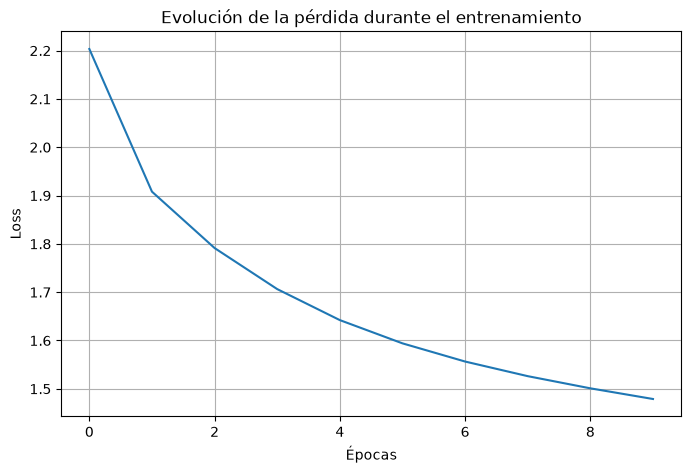

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"])
plt.title("Evolución de la pérdida durante el entrenamiento")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

### **Análisis de la pérdida durante el entrenamiento:**

El gráfico muestra la evolución de la pérdida (`loss`) durante el entrenamiento del modelo LSTM.

Se observa que la pérdida disminuye progresivamente a medida que avanzan las épocas, comenzando aproximadamente sobre 2.18 y llegando a un valor cercano a 1.45 al finalizar el entrenamiento. Esto indica que el modelo está aprendiendo patrones del texto y mejora su capacidad para predecir el siguiente carácter.

La disminución de la pérdida es más marcada durante las primeras épocas, lo que significa que el modelo aprende rápidamente las relaciones más básicas del lenguaje, como la aparición de espacios, letras frecuentes y combinaciones comunes de caracteres.

En las últimas épocas la pérdida continúa bajando, pero de manera más lenta. Esto es esperable, ya que después de aprender patrones generales, el modelo necesita más entrenamiento para capturar estructuras más complejas del texto.

En conclusión, el comportamiento de la curva es positivo, ya que no se observan aumentos bruscos ni inestabilidad. Esto sugiere que el entrenamiento fue adecuado y que el modelo logró mejorar época a época.

---
---

## Entregable

Completa los apartados anteriores para entrenar modelos del lenguaje que sean capaces de generar texto con cierto sentido. Comentar los resultados obtenidos y cómo el modelo va mejorando época a época. Comentar las diferencias apreciadas al utilizar diferentes valores de temperatura. Entregar al menos la salida de un entrenamiento completo con los textos generados época a época.

El objetivo no es conseguir generar pasajes literarios con coherencia, sino obtener lenguaje que se asemeje en cierta manera a lo visto en el texto original y donde las palabras sean reconocibles como construcciones en castellano. Como ejemplo de lo que se puede conseguir, este es el resultado de generar texto después de 10 epochs y con temperature 0.2:


```
-----> Epoch: 10 - Generando texto con temperature 0.2
Seed: o le cautivaron y rindieron el
Texto generado: o le cautivaron y rindieron el caballero de la caballería de la mano de la caballería del cual se le dijo:

-¿quién es el verdad de la caballería de la caballería de la caballería de la caballería de la caballería, y me ha de habían de la mano que el caballero de la mano de la caballería. y que no se le habían de la mano de la c

```

Asimismo, se proponen los siguientes aspectos opcionales para conseguir nota extra:

*   Experimentar con los textos de teatro en verso de Calderón de la Barca (¿es capaz el modelo de aprender las estructuras del teatro en verso?) o con alguno de los otros textos disponibles. También se puede probar con textos de vuestra elección.
*   Experimentar con distintos valores de SEQ_LENGTH.
*   Experimentar con los hiperparámetros del modelo o probar otro tipo de modelos como GRUs o *stacked* RNNs (RNNs apiladas).
*   Experimentar utilizando embeddings en vez de representaciones one-hot.
*   (Difícil) Entrenar un modelo secuencia a secuencia en vez de secuencia a carácter.




# 4. **Desarrollo de aspectos opcionales:**
A continuación, se desarrollarán los experimentos adicionales indicados de manera separada para poder analizar de mejor manera el comportamiento de cada uno de ellos.

## 4.1 Experimento con los textos de teatro en verso de Calderón de la Barca.

En este experimento se utiliza un texto de teatro de Pedro Calderón de la Barca para analizar si el modelo es capaz de aprender patrones distintos a los presentes en *Don Quijote de la Mancha*.

A diferencia de una novela, el teatro en verso presenta una estructura particular. Puede incluir nombres de personajes, intervenciones dialogadas, versos más breves, cambios de hablante y una organización más marcada por escenas o jornadas.

El objetivo de este experimento es observar si un modelo recurrente puede adaptarse a un corpus diferente y generar texto con características similares al teatro clásico en verso.

Para mantener una comparación justa con los experimentos anteriores, se utilizará una arquitectura LSTM similar, el mismo `SEQ_LENGTH`, el mismo batch size y la misma cantidad de épocas.

### 4.1.1 Carga del texto de Calderón.

El texto seleccionado corresponde a *Teatro selecto, tomo 1 de 4*, que contiene varias obras teatrales de Calderón. Esta elección permite trabajar con un corpus diferente al Quijote y evaluar si el modelo aprende patrones asociados al teatro.

In [ ]:
import requests

url_calderon = "https://www.gutenberg.org/files/54436/54436-0.txt"

response = requests.get(url_calderon)
response.encoding = "utf-8"

text_calderon = response.text.lower()

print("Texto de Calderón descargado.")
print("Longitud inicial:", len(text_calderon))
print(text_calderon[:1000])

Texto de Calderón descargado.
Longitud inicial: 530335
*** start of the project gutenberg ebook 54436 ***

nota de transcripción

  * las cursivas se muestran entre _subrayados_ y las versalitas se
    han convertido a mayúsculas.

  * los errores de imprenta han sido corregidos sin avisar. para su
    detección se han tenido en cuenta otras ediciones de estos dramas.

  * se ha respetado la ortografía original, normalizándola a la
    grafía de mayor frecuencia. también se han respetado las
    inconsistencias en la acentuación.

  * no obstante, se han incorporado los siguientes cambios:

      p.  xvii: bolh de faber → böhl de faber
      p. xlvii:    copavacana → copacabana
      p.   335:    escena vi. → escena iv.

  * se han reparado los emparejamientos de los signos de admiración
    e interrogación.

  * las notas a pie de página se han renumerado y colocado tras el
    párrafo o la estrofa en que se encuentra la llamada.

  * en el original impreso, las indicaciones escénicas

### 4.1.2 Limpiar texto de Calderón.

El archivo descargado contiene encabezados, notas editoriales y secciones propias de Project Gutenberg. Por esta razón, se realiza una limpieza básica para trabajar principalmente con el contenido literario.

Además, se eliminan saltos de línea excesivos y se normalizan los espacios para facilitar el entrenamiento del modelo.

In [ ]:
# Buscamos un punto de inicio más cercano al contenido teatral:
posibles_inicios = [
    "la vida es sueño",
    "jornada primera",
    "acto primero"
]

inicio = -1

for marcador in posibles_inicios:
    pos = text_calderon.find(marcador)
    if pos != -1:
        inicio = pos
        print("Inicio encontrado en:", marcador)
        break

if inicio != -1:
    text_calderon = text_calderon[inicio:]
else:
    print("No se encontró marcador de inicio. Se usará el texto completo.")

# Eliminamos posible pie de Gutenberg:
fin = text_calderon.find("*** end of the project gutenberg ebook")

if fin != -1:
    text_calderon = text_calderon[:fin]

# Limpieza básica:
text_calderon = text_calderon.replace("\r", " ")
text_calderon = text_calderon.replace("\n", " ")
text_calderon = " ".join(text_calderon.split())

print("Longitud final:", len(text_calderon))
print(text_calderon[:1000])

Inicio encontrado en: la vida es sueño
Longitud final: 461986
la vida es sueño. la devocion de la cruz. el mágico prodigioso. el príncipe constante. madrid luis navarro, editor colegiata, núm. 6 1881 estudio crítico. justa y noble cosa es que los pueblos honren la memoria de sus grandes poetas; pero si he de decir lo que siento, ántes me parece funesto que útil el entusiasmo oficial y la devocion obligada, que produce los aniversarios y centenarios, con el obligado cortejo de músicas, carros triunfales, pompas y apariencias, versos y justas poéticas. aun lo bueno sobre un mismo asunto empalaga, cuando es demasiado: ¿qué será cuando en la turbia corriente de tales solemnidades rueda tanto de mediano y áun de malo? la secta de los cervantistas acabaria, á no ser tan grande el personaje á quien injurian y apedrean, por hacer aborrecible hasta el nombre de cervántes en la memoria de las gentes. ¿quién sabe si conseguirán otro tanto los calderonianos, á fuerza de sacrificar en las aras de s

### 4.1.3 Caracteres y diccionarios del texto de Calderón.

Como el corpus de Calderón puede tener caracteres distintos al texto del Quijote, se crean nuevos diccionarios de caracteres.

Estos diccionarios permiten transformar cada carácter en un índice numérico y luego convertir las predicciones del modelo nuevamente a texto.

In [ ]:
chars_calderon = sorted(list(set(text_calderon)))
NUM_CHARS_CALDERON = len(chars_calderon)

char_to_indices_calderon = {char: i for i, char in enumerate(chars_calderon)}
indices_to_char_calderon = {i: char for i, char in enumerate(chars_calderon)}

print("Número de caracteres únicos en Calderón:", NUM_CHARS_CALDERON)
print("Primeros caracteres:", chars_calderon[:50])

Número de caracteres únicos en Calderón: 69
Primeros caracteres: [' ', '!', '(', ')', '*', ',', '-', '.', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '?', '[', ']', '_', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'x', 'y', 'z', '}']


### 4.1.4 Creación de secuencias para Calderón.

El modelo se entrenará con un enfoque secuencia a carácter. Esto significa que recibirá una secuencia de caracteres y deberá predecir el carácter siguiente.

Se mantiene `SEQ_LENGTH = 30` para comparar este experimento con el modelo base entrenado sobre *Don Quijote de la Mancha*.

In [ ]:
SEQ_LENGTH_CALDERON = 30
MAX_SEQUENCES_CALDERON = 100000
STEP_CALDERON = 3

def crear_dataset_calderon(texto, seq_length, chars, char_to_indices, max_sequences=100000, step=3):
    sequences = []
    next_chars = []

    for i in range(0, len(texto) - seq_length, step):
        sequences.append(texto[i:i + seq_length])
        next_chars.append(texto[i + seq_length])

        if len(sequences) >= max_sequences:
            break

    X_cald = np.zeros((len(sequences), seq_length, len(chars)), dtype=np.bool_)
    y_cald = np.zeros((len(sequences), len(chars)), dtype=np.bool_)

    for i, sequence in enumerate(sequences):
        for t, char in enumerate(sequence):
            X_cald[i, t, char_to_indices[char]] = 1

        y_cald[i, char_to_indices[next_chars[i]]] = 1

    return X_cald, y_cald, sequences, next_chars

In [ ]:
X_calderon, y_calderon, sequences_calderon, next_chars_calderon = crear_dataset_calderon(
    texto=text_calderon,
    seq_length=SEQ_LENGTH_CALDERON,
    chars=chars_calderon,
    char_to_indices=char_to_indices_calderon,
    max_sequences=MAX_SEQUENCES_CALDERON,
    step=STEP_CALDERON
)

print("Shape X_calderon:", X_calderon.shape)
print("Shape y_calderon:", y_calderon.shape)

print("\nEjemplo de secuencia:")
print(sequences_calderon[0])

print("\nCarácter siguiente:")
print(next_chars_calderon[0])

Shape X_calderon: (100000, 30, 69)
Shape y_calderon: (100000, 69)

Ejemplo de secuencia:
la vida es sueño. la devocion 

Carácter siguiente:
d


### 4.1.5 Definición del modelo para Calderón.

Se utiliza una arquitectura LSTM similar a la usada con el Quijote, para que la comparación se centre principalmente en el cambio de corpus.

La capa LSTM contiene 128 unidades, ya que este valor ofrece una capacidad suficiente para aprender patrones de secuencias sin aumentar demasiado el costo computacional.

La capa final utiliza `softmax`, porque el modelo debe escoger el carácter más probable entre todos los caracteres únicos del texto de Calderón.

In [ ]:
def crear_modelo_calderon(seq_length, num_chars):
    model_calderon = Sequential()

    model_calderon.add(LSTM(
        128,
        input_shape=(seq_length, num_chars)
    ))

    model_calderon.add(Dense(num_chars, activation="softmax"))

    model_calderon.compile(
        loss="categorical_crossentropy",
        optimizer="adam"
    )

    return model_calderon

In [ ]:
modelo_calderon = crear_modelo_calderon(
    seq_length=SEQ_LENGTH_CALDERON,
    num_chars=NUM_CHARS_CALDERON
)

modelo_calderon.summary()

c:\Users\Ignacia\Desktop\Don_Quijote\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_11 (LSTM)                  │ (None, 128)            │       101,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 69)             │         8,901 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,277 (430.77 KB)

 Trainable params: 110,277 (430.77 KB)

 Non-trainable params: 0 (0.00 B)

### 4.1.6 Entrenamiento del modelo con Calderón.

El modelo se entrena durante 10 épocas, manteniendo el batch size en 128 para conservar una configuración similar al modelo base.

El objetivo no es obtener una generación literaria perfecta, sino observar si el modelo logra aprender patrones básicos del teatro en verso, como palabras reconocibles, estructuras de diálogo o secuencias similares al corpus teatral.

In [ ]:
EPOCHS_CALDERON = 10
BATCH_SIZE_CALDERON = 128

history_calderon = modelo_calderon.fit(
    X_calderon,
    y_calderon,
    batch_size=BATCH_SIZE_CALDERON,
    epochs=EPOCHS_CALDERON,
    verbose=1
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 33ms/step - loss: 2.6929
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - loss: 2.2670
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - loss: 2.1609
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 39s 30ms/step - loss: 2.0998
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 30ms/step - loss: 2.0508
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 43s 32ms/step - loss: 2.0137
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 45s 38ms/step - loss: 1.9819
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 37s 33ms/step - loss: 1.9525
Epoch 9/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 33ms/step - loss: 1.9246
Epoch 10/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 40s 33ms/step - loss: 1.8994


### 4.1.7 Gráfico de pérdida.

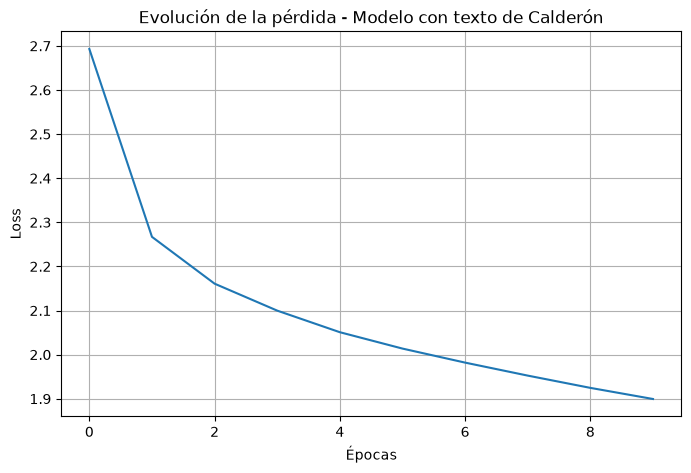

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history_calderon.history["loss"])
plt.title("Evolución de la pérdida - Modelo con texto de Calderón")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

### Análisis de la pérdida del modelo con texto de Calderón.

El gráfico muestra la evolución de la pérdida durante el entrenamiento del modelo LSTM utilizando textos de teatro en verso de Calderón de la Barca.

Se observa que la pérdida disminuye de forma progresiva a medida que avanzan las épocas, comenzando aproximadamente en 2.70 y finalizando cerca de 1.90. Esta disminución indica que el modelo logró aprender patrones del corpus y mejorar su capacidad para predecir el siguiente carácter.

La caída más fuerte ocurre durante las primeras épocas, especialmente entre la época 0 y la época 1. Esto sugiere que el modelo aprende rápidamente patrones básicos del texto, como combinaciones frecuentes de letras, espacios y estructuras comunes del lenguaje.

En las épocas posteriores, la pérdida continúa bajando, pero de manera más lenta. Esto es esperable, ya que después de aprender patrones básicos, el modelo necesita más entrenamiento para capturar estructuras más complejas del teatro en verso.

Aunque la pérdida final sigue siendo relativamente alta en comparación con otros experimentos, el comportamiento de la curva es positivo porque no presenta aumentos bruscos ni inestabilidad. Esto indica que el modelo sí está aprendiendo, pero que el corpus de Calderón puede ser más difícil de modelar debido a su estructura teatral, presencia de diálogos, versos, nombres de personajes y cambios de intervención.

En conclusión, el modelo logró aprender patrones generales del texto de Calderón, aunque probablemente necesitaría más épocas, más datos o una arquitectura más compleja para generar texto con mayor coherencia.

### 4.1.8 Generación de texto con el modelo de Calderón.

Para generar texto con el modelo entrenado sobre Calderón, se utiliza una semilla inicial y se predice carácter por carácter.

Se generan textos con distintas temperaturas para observar cómo cambia la estabilidad y creatividad del modelo.

In [ ]:
def sample_calderon(preds, temperature=1.0):
    preds = np.asarray(preds).astype("float64")
    preds = np.log(preds + 1e-8) / temperature
    exp_preds = np.exp(preds)
    preds = exp_preds / np.sum(exp_preds)

    probas = np.random.multinomial(1, preds, 1)
    return np.argmax(probas)

In [ ]:
def generate_text_calderon(seed_text, model, length, temperature=1.0):
    generated = seed_text.lower()

    if len(generated) < SEQ_LENGTH_CALDERON:
        generated = generated.rjust(SEQ_LENGTH_CALDERON)

    for i in range(length):
        sentence = generated[-SEQ_LENGTH_CALDERON:]

        X_pred = np.zeros((1, SEQ_LENGTH_CALDERON, NUM_CHARS_CALDERON), dtype=np.bool_)

        for t, char in enumerate(sentence):
            if char in char_to_indices_calderon:
                X_pred[0, t, char_to_indices_calderon[char]] = 1

        preds = model.predict(X_pred, verbose=0)[0]

        next_index = sample_calderon(preds, temperature)
        next_char = indices_to_char_calderon[next_index]

        generated += next_char

    return generated

### 4.1.9 Generación con distintas temperaturas.

Se entrenará el modelo con las siguientes temperaturas para visualizar su comportamiento:
- 0.2
- 0.5
- 1.0
- 1.2

In [ ]:
seed_calderon = "jornada primera"

for temp in [0.2, 0.5, 1.0, 1.2]:
    print("\n" + "="*80)
    print(f"Texto generado con Calderón - Temperatura {temp}")
    print("="*80)

    texto_generado = generate_text_calderon(
        seed_text=seed_calderon,
        model=modelo_calderon,
        length=400,
        temperature=temp
    )

    print(texto_generado)


Texto generado con Calderón - Temperatura 0.2
               jornada primera la de parte de la de te son esto de la de la de conte de la de la viendo en la de por el conte te de conte te viento es esta de la condicion de la verto es de esta de la la de la me de su ha de perte la como lo de la de la de la me de mi para la la tan de la se la de tondo en esta de la de la conte la de la sengio en esto de de la de tondo en la de la carte de la se de te de la de la de la condic

Texto generado con Calderón - Temperatura 0.5
               jornada primera de su cuisto á la hay con estera de la guerto de la vierto estre se de perte de en lo vedie el algicionos de dista de estrivio y es cuerta de su se tar escona la garse de la verte se ver su el me dio tual de á lo has mez rosario de la los eusondo aderto de atrobiendo que es el pies se cuego que algo el pues escenos de cuerto en en estuerte de la la vellos de las destua le con viendo á los como de

Texto generado con Calderón - Temperatura 1

### 4.1.10 Comparación entre Quijote y Calderón.

Se compara el modelo entrenado con *Don Quijote de la Mancha* y el modelo entrenado con textos teatrales de Calderón.

Aunque ambos modelos usan una arquitectura similar, el corpus es diferente. El Quijote corresponde a una novela narrativa, mientras que Calderón corresponde a teatro, con mayor presencia de diálogos y estructuras escénicas.

In [ ]:
df_comparacion_corpus = pd.DataFrame({
    "Corpus": [
        "Don Quijote de la Mancha",
        "Teatro de Calderón"
    ],
    "Tipo de texto": [
        "Novela narrativa",
        "Teatro en verso"
    ],
    "Loss final": [
        history.history["loss"][-1],
        history_calderon.history["loss"][-1]
    ],
    "SEQ_LENGTH": [
        SEQ_LENGTH,
        SEQ_LENGTH_CALDERON
    ],
    "Épocas": [
        len(history.history["loss"]),
        len(history_calderon.history["loss"])
    ],
    "Batch size": [
        128,
        BATCH_SIZE_CALDERON
    ]
})

df_comparacion_corpus.style \
    .format({"Loss final": "{:.4f}"}) \
    .hide(axis="index") \
    .set_caption("Comparación entre corpus: Quijote vs Calderón") \
    .highlight_min(subset=["Loss final"], color="#c8e6c9")

Corpus,Tipo de texto,Loss final,SEQ_LENGTH,Épocas,Batch size
Don Quijote de la Mancha,Novela narrativa,1.4789,30,10,128
Teatro de Calderón,Teatro en verso,1.8994,30,10,128


### 4.1.11 Gráfico comparativo.

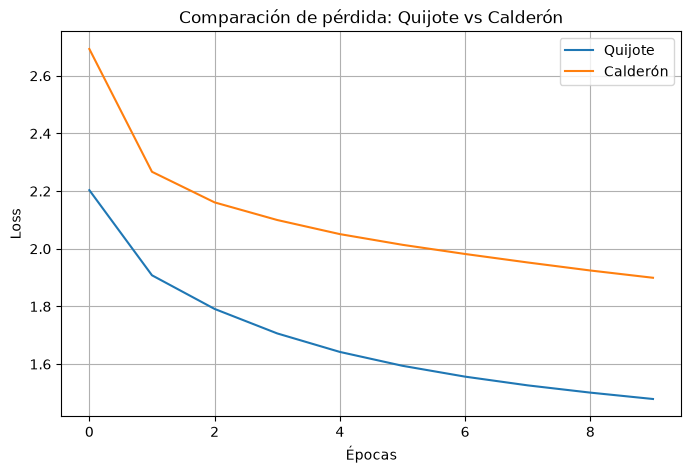

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Quijote")
plt.plot(history_calderon.history["loss"], label="Calderón")

plt.title("Comparación de pérdida: Quijote vs Calderón")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

### 4.1.12 Análisis del experimento entre Calderón de la Barca y Don Quijote.

En este experimento se comparó el entrenamiento de un modelo LSTM utilizando dos corpus distintos: *Don Quijote de la Mancha* y textos teatrales de Calderón de la Barca.

En el gráfico se observa que ambos modelos disminuyen su pérdida a medida que avanzan las épocas. Esto indica que, en ambos casos, el modelo logró aprender patrones del texto y mejorar su capacidad para predecir el siguiente carácter.

Sin embargo, el modelo entrenado con *Don Quijote de la Mancha* obtuvo una pérdida menor durante todo el entrenamiento. Al finalizar las épocas, la loss del modelo con Quijote fue cercana a 1.48, mientras que la del modelo con Calderón fue cercana a 1.90.

Esta diferencia puede deberse a que ambos corpus tienen estructuras distintas. El Quijote corresponde a una novela narrativa, con frases más continuas y una estructura textual más uniforme. En cambio, el texto de Calderón corresponde a teatro en verso, donde pueden aparecer nombres de personajes, diálogos, versos breves, cambios de intervención y estructuras escénicas. Esto puede hacer que el patrón del texto sea más difícil de aprender para un modelo carácter a carácter.

También es importante considerar que una loss mayor en Calderón no significa que el modelo no haya aprendido. La curva baja de forma progresiva, lo que demuestra aprendizaje. Sin embargo, el modelo necesitó más esfuerzo para adaptarse a la estructura del teatro.

En conclusión, el experimento muestra que el tipo de corpus influye directamente en el entrenamiento del modelo. Aunque se mantenga la misma arquitectura, el modelo aprende con mayor facilidad textos narrativos continuos como el Quijote, mientras que textos teatrales en verso pueden requerir más épocas, mayor cantidad de datos o una arquitectura más compleja para obtener mejores resultados.

---
---

## 4.2 Experimento con distintos valores de SEQ_LENGTH.

En este experimento se evalúa cómo cambia el comportamiento del modelo al modificar el valor de `SEQ_LENGTH`.

El parámetro `SEQ_LENGTH` define cuántos caracteres anteriores recibe el modelo para intentar predecir el siguiente carácter. Por ejemplo, si `SEQ_LENGTH = 30`, el modelo observa una secuencia de 30 caracteres y aprende a predecir el carácter número 31.

Modificar este valor permite analizar la importancia del contexto en la generación de texto:

- Un valor bajo de `SEQ_LENGTH` entrega menos contexto, por lo que el modelo puede entrenar más rápido, pero generar texto menos coherente.
- Un valor alto entrega más contexto, lo que puede ayudar a generar texto con mayor estructura, pero aumenta el costo computacional y el tiempo de entrenamiento.

Para comparar los resultados, se entrenarán modelos con distintos valores de `SEQ_LENGTH`, manteniendo constantes otros hiperparámetros como el optimizador, la cantidad de unidades LSTM, el batch size y el número de épocas.

### 4.2.1 Función para crear secuencias según SEQ_LENGTH.

Como el tamaño de la secuencia cambia, es necesario volver a construir los datos de entrada `X` y salida `y` para cada experimento.

Cada modelo recibirá una cantidad distinta de caracteres como contexto, pero siempre intentará predecir el carácter siguiente.

In [ ]:
def crear_dataset_secuencias(text, seq_length, chars, char_to_indices, max_sequences=100000, step=3):
    sequences = []
    next_chars = []

# Se cambia a "seq_length" para evitar problemas con "SEQ_LENGTH" utilizado anteriormente:
    for i in range(0, len(text) - seq_length, step):
        sequences.append(text[i:i + seq_length])
        next_chars.append(text[i + seq_length])

        if len(sequences) >= max_sequences:
            break

    num_sequences = len(sequences)
    num_chars = len(chars)

    X_temp = np.zeros((num_sequences, seq_length, num_chars), dtype=np.bool_)
    y_temp = np.zeros((num_sequences, num_chars), dtype=np.bool_)

    for i, sequence in enumerate(sequences):
        for t, char in enumerate(sequence):
            X_temp[i, t, char_to_indices[char]] = 1

        y_temp[i, char_to_indices[next_chars[i]]] = 1

    return X_temp, y_temp, sequences, next_chars

### 4.2.2 Función para crear modelo LSTM según SEQ_LENGTH.

Para comparar correctamente los valores de `SEQ_LENGTH`, se mantiene la misma arquitectura base del modelo LSTM.

La única diferencia entre los experimentos será la cantidad de caracteres que recibe el modelo como entrada.

In [ ]:
def crear_modelo_lstm_seq(seq_length, num_chars):
    model_seq = Sequential()

    model_seq.add(LSTM(
        128,
        input_shape=(seq_length, num_chars)
    ))

    model_seq.add(Dense(num_chars, activation="softmax"))

    model_seq.compile(
        loss="categorical_crossentropy",
        optimizer="adam"
    )

    return model_seq

### 4.2.3 Generación de texto con modelos de distinto SEQ_LENGTH.

Como cada modelo fue entrenado con un largo de secuencia diferente, la función de generación debe utilizar el mismo `SEQ_LENGTH` con el que fue entrenado el modelo.

Esto evita errores de dimensión y permite comparar los textos generados de manera correcta.

In [ ]:
def generate_text_seq(seed_text, model, length, seq_length, temperature=1.0):
    generated = seed_text.lower()

    if len(generated) < seq_length:
        generated = generated.rjust(seq_length)

    for i in range(length):
        sentence = generated[-seq_length:]

        X_pred = np.zeros((1, seq_length, NUM_CHARS), dtype=np.bool_)

        for t, char in enumerate(sentence):
            if char in char_to_indices:
                X_pred[0, t, char_to_indices[char]] = 1

        preds = model.predict(X_pred, verbose=0)[0]

        next_index = sample(preds, temperature)
        next_char = indices_to_char[next_index]

        generated += next_char

    return generated

### 4.2.4 Entrenamiento de modelos con distintos valores de SEQ_LENGTH.

Se entrenan modelos utilizando distintos valores de `SEQ_LENGTH`. Para que la comparación sea justa, se mantienen constantes los demás hiperparámetros.

En este experimento se utiliza una cantidad limitada de secuencias para evitar un consumo excesivo de memoria, ya que al aumentar `SEQ_LENGTH` también aumenta el tamaño de los datos codificados en one-hot.

In [ ]:
seq_lengths = [20, 30, 60]

EPOCHS_SEQ = 10
BATCH_SIZE_SEQ = 128
MAX_SEQUENCES_SEQ = 100000

resultados_seq = []
modelos_seq = {}
histories_seq = {}

for seq_len in seq_lengths:
    print("\n" + "="*80)
    print(f"Entrenando modelo con SEQ_LENGTH = {seq_len}")
    print("="*80)

    X_seq, y_seq, sequences_seq, next_chars_seq = crear_dataset_secuencias(
        text=text,
        seq_length=seq_len,
        chars=chars,
        char_to_indices=char_to_indices,
        max_sequences=MAX_SEQUENCES_SEQ,
        step=3
    )

    print("Shape X:", X_seq.shape)
    print("Shape y:", y_seq.shape)

    model_seq = crear_modelo_lstm_seq(seq_len, NUM_CHARS)

    history_seq = model_seq.fit(
        X_seq,
        y_seq,
        batch_size=BATCH_SIZE_SEQ,
        epochs=EPOCHS_SEQ,
        verbose=1
    )

    modelos_seq[seq_len] = model_seq
    histories_seq[seq_len] = history_seq

    final_loss = history_seq.history["loss"][-1]

    resultados_seq.append({
        "SEQ_LENGTH": seq_len,
        "Loss final": final_loss
    })


Entrenando modelo con SEQ_LENGTH = 20
Shape X: (100000, 20, 61)
Shape y: (100000, 61)
Epoch 1/10


c:\Users\Ignacia\Desktop\Don_Quijote\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 22ms/step - loss: 2.6389
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - loss: 2.2015
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - loss: 2.0928
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - loss: 2.0273
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - loss: 1.9740
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - loss: 1.9306
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 23ms/step - loss: 1.8925
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 26ms/step - loss: 1.8572
Epoch 9/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - loss: 1.8266
Epoch 10/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - loss: 1.7963

Entrenando modelo con SEQ_LENGTH = 30
Shape X: (100000, 30, 61)
Shape y: (100000, 61)
Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 32ms/step - loss: 2.6482
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - loss: 2.2094
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 42s 34ms/step - loss: 2.0929
Epoch 4/10
782/782 ━━━━━━━

### 4.2.5 Comparación de resultados.

La siguiente tabla muestra la pérdida final obtenida por cada modelo entrenado con distintos valores de `SEQ_LENGTH`.

Un menor valor de pérdida indica que el modelo logró predecir mejor el siguiente carácter durante el entrenamiento.

In [ ]:
df_resultados_seq = pd.DataFrame(resultados_seq)
df_resultados_seq.sort_values(by="Loss final", ascending=True)

df_resultados_seq.sort_values(by="Loss final", ascending=True).style \
    .format({"Loss final": "{:.4f}"}) \
    .hide(axis="index") \
    .set_caption("Comparación de modelos con distintos valores de SEQ_LENGTH") \
    .highlight_min(subset=["Loss final"], color="#c8e6c9")

SEQ_LENGTH,Loss final
60,1.7577
20,1.7963
30,1.8350


### 4.2.6 Gráfico comparativo de pérdida.

Se grafican las curvas de pérdida de cada experimento para observar cómo evoluciona el entrenamiento con distintos valores de `SEQ_LENGTH`.

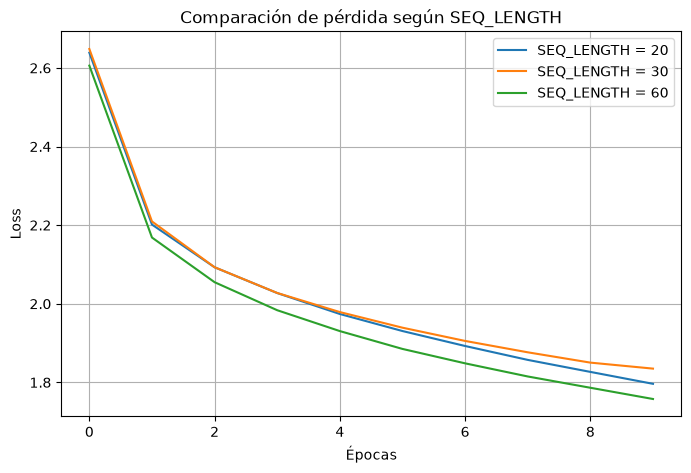

In [ ]:
plt.figure(figsize=(8,5))

for seq_len, history_seq in histories_seq.items():
    plt.plot(
        history_seq.history["loss"],
        label=f"SEQ_LENGTH = {seq_len}"
    )

plt.title("Comparación de pérdida según SEQ_LENGTH")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

### Análisis de la pérdida con distintos valores de SEQ_LENGTH.

En este experimento se compararon tres valores de `SEQ_LENGTH`: 20, 30 y 60. Este parámetro indica cuántos caracteres anteriores recibe el modelo para predecir el siguiente carácter.

En el gráfico se observa que los tres modelos reducen progresivamente la pérdida durante el entrenamiento, lo que indica que todos lograron aprender patrones del texto.

La disminución más fuerte ocurre en las primeras épocas, donde el modelo aprende patrones básicos como combinaciones frecuentes de letras, espacios y estructuras comunes de palabras. Luego, la pérdida continúa bajando de forma más lenta, lo que es esperable porque el modelo comienza a ajustar patrones más complejos.

Según la tabla comparativa, el mejor resultado lo obtuvo `SEQ_LENGTH = 60`, con una pérdida final de aproximadamente 1.7577. Esto indica que, en este experimento, entregar más contexto al modelo ayudó a mejorar la predicción del siguiente carácter.

El modelo con `SEQ_LENGTH = 20` obtuvo una pérdida final cercana a 1.7963, mientras que `SEQ_LENGTH = 30` obtuvo una pérdida aproximada de 1.8350. Esto muestra que, bajo esta configuración, una secuencia más larga permitió al modelo aprovechar mejor la información previa del texto.

Sin embargo, usar un `SEQ_LENGTH` más alto también implica un mayor costo computacional, ya que el modelo debe procesar secuencias más largas. Por esta razón, aunque `SEQ_LENGTH = 60` obtuvo el mejor resultado, también requiere más recursos que valores más pequeños.

En conclusión, el valor de `SEQ_LENGTH` influye directamente en el aprendizaje del modelo. Para este experimento, el mejor desempeño se logró con `SEQ_LENGTH = 60`, ya que obtuvo la menor pérdida final.

### 4.2.7 Generación de texto según SEQ_LENGTH.

Finalmente, se genera texto con cada modelo entrenado para comparar cualitativamente los resultados.

Se utiliza la misma semilla y temperatura para que la comparación sea más clara.

In [ ]:
seed_text = "en un lugar de la mancha de cuyo nombre"
temperature = 0.5

for seq_len, model_seq in modelos_seq.items():
    print("\n" + "="*80)
    print(f"Texto generado con SEQ_LENGTH = {seq_len}")
    print("="*80)

    texto_generado = generate_text_seq(
        seed_text=seed_text,
        model=model_seq,
        length=400,
        seq_length=seq_len,
        temperature=temperature
    )

    print(texto_generado)


Texto generado con SEQ_LENGTH = 20
en un lugar de la mancha de cuyo nombre de su vien a dos que la más armino es de camo y esta anguna y de la fuesto se preto y le viere tan del al cimido de se precho ambre y de suncha senda de la parto de aquel sabí, se prescuallo, y a mar de por a las para desa parta de su caballero de se su merme, y que el complero de la mus de masta de la tal prigo. a vel camblero y a dono que en alguna de su cabelloro hal caballero de malas en el m

Texto generado con SEQ_LENGTH = 30
en un lugar de la mancha de cuyo nombre el mán se
recar al caballara me cobre con visto trentas que le con alguna a todo que la verteros y de la puestra me mido la cubiento su esta de la de pura de le la manerra de se la miento de la mara de vintido allgara como esta que lo con tan quijote calos y armo de lo mara cual diente estra con que los compos que ton que la velar ten muerte parte se estaba de los de la minta la mala y anza a do 

Texto generado con SEQ_LENGTH = 60
            

### 4.2.8 Análisis del experimento.

Este experimento permitió evaluar cómo influye el tamaño de la secuencia de entrada en el aprendizaje del modelo LSTM.

El parámetro SEQ_LENGTH determina cuántos caracteres anteriores utiliza el modelo como contexto para predecir el siguiente carácter. Por esta razón, modificar este valor cambia directamente la cantidad de información que recibe la red antes de realizar una predicción.

Un valor menor de SEQ_LENGTH permite entrenar con secuencias más cortas, lo que reduce el costo computacional y puede hacer que el entrenamiento sea más rápido. Sin embargo, también limita la cantidad de contexto disponible, por lo que el modelo puede tener más dificultad para capturar relaciones más largas dentro del texto.

Por otro lado, un valor mayor de SEQ_LENGTH entrega más contexto al modelo. Esto puede ayudar a aprender estructuras más amplias del lenguaje, como combinaciones de palabras, frases o patrones más largos. Aun así, también aumenta la complejidad del entrenamiento, ya que la red debe procesar secuencias más extensas.

Este experimento demuestra que SEQ_LENGTH es un hiperparámetro importante en modelos de generación de texto, ya que afecta tanto el rendimiento del modelo como el costo computacional. Por eso, su elección debe considerar un equilibrio entre cantidad de contexto, tiempo de entrenamiento y calidad del texto generado.

En general, probar distintos valores de SEQ_LENGTH permitió observar que la generación de texto no depende solamente de la arquitectura del modelo, sino también de cómo se construyen las secuencias de entrada.

---
---

## 4.3 Experimento con hiperparámetros del modelo o probar otro tipo de modelos.

En este experimento se comparan distintas arquitecturas recurrentes para analizar cómo cambia el aprendizaje del modelo al modificar su estructura interna.

El modelo base utilizado anteriormente corresponde a una LSTM simple. En esta sección se compara ese resultado con una GRU y con una LSTM apilada.

La GRU es una arquitectura recurrente similar a la LSTM, pero con una estructura interna más simple. Esto puede permitir un entrenamiento más rápido, aunque con menor capacidad para capturar dependencias largas en algunos casos.

Por otro lado, una LSTM apilada utiliza más de una capa recurrente. Esto aumenta la capacidad del modelo para aprender patrones más complejos del texto, aunque también incrementa el costo computacional y el riesgo de sobreajuste.

Para realizar una comparación justa, se mantiene el mismo dataset, el mismo `SEQ_LENGTH`, el mismo batch size, el mismo número de épocas, el optimizador Adam y la función de pérdida `categorical_crossentropy`.

### 4.3.1 Variables comunes del experimento.

Se definen los hiperparámetros comunes para entrenas los modelos comparados. Mantener estos valores constantes permite que la comparación dependa principalmente del cambio de arquitectura.

In [ ]:
from tensorflow.keras.layers import GRU

EPOCHS_EXTRA = 10
BATCH_SIZE_EXTRA = 128

resultados_extra = []
modelos_extra = {}
histories_extra = {}

### 4.3.2 Función auxiliar de entrenamiento.

Se define una función auxiliar para entrenar cada modelo, guardar su historial y registrar la pérdida final. Esta pérdida permitirá comparar cuantitativamente qué arquitectura aprendió mejor a predecir el siguiente carácter.

In [ ]:
def entrenar_modelo_extra(nombre_modelo, modelo):
    print("\n" + "="*80)
    print(f"Entrenando modelo: {nombre_modelo}")
    print("="*80)

    history_temp = modelo.fit(
        X,
        y,
        batch_size=BATCH_SIZE_EXTRA,
        epochs=EPOCHS_EXTRA,
        verbose=1
    )

    modelos_extra[nombre_modelo] = modelo
    histories_extra[nombre_modelo] = history_temp

    loss_final = history_temp.history["loss"][-1]

    resultados_extra.append({
        "Modelo": nombre_modelo,
        "Loss final": loss_final,
        "Épocas": EPOCHS_EXTRA,
        "Batch size": BATCH_SIZE_EXTRA,
        "SEQ_LENGTH": SEQ_LENGTH
    })

    return history_temp

### 4.3.3 Registrar LSTM base como referencia.

El modelo LSTM entrenado previamente se utiliza como referencia para comparar los nuevos modelos recurrentes. Esto permite analizar si una GRU o una LSTM apilada mejora o no el resultado obtenido inicialmente.

In [ ]:
# Guardamos el modelo LSTM base como referencia, sin volver a entrenarlo:

modelos_extra["LSTM base"] = model
histories_extra["LSTM base"] = history

resultados_extra.append({
    "Modelo": "LSTM base",
    "Loss final": history.history["loss"][-1],
    "Épocas": len(history.history["loss"]),
    "Batch size": 128,
    "SEQ_LENGTH": SEQ_LENGTH
})

### 4.3.4 Modelo GRU.

En este experimento se reemplaza la capa LSTM por una capa GRU.

La GRU también es una red recurrente diseñada para trabajar con secuencias, pero tiene una estructura interna más simple que la LSTM. Esto puede hacer que entrene más rápido, manteniendo una buena capacidad para aprender dependencias en el texto.

El objetivo es comparar si una GRU logra generar texto con una pérdida similar o menor que la LSTM base.

In [ ]:
def crear_modelo_gru():
    model_gru = Sequential()

    model_gru.add(GRU(
        128,
        input_shape=(SEQ_LENGTH, NUM_CHARS)
    ))

    model_gru.add(Dense(NUM_CHARS, activation="softmax"))

    model_gru.compile(
        loss="categorical_crossentropy",
        optimizer="adam"
    )

    return model_gru

In [ ]:
modelo_gru = crear_modelo_gru()
modelo_gru.summary()

history_gru = entrenar_modelo_extra(
    "GRU 128 unidades",
    modelo_gru
)

c:\Users\Ignacia\Desktop\Don_Quijote\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 128)            │        73,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 61)             │         7,869 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81,213 (317.24 KB)

 Trainable params: 81,213 (317.24 KB)

 Non-trainable params: 0 (0.00 B)


Entrenando modelo: GRU 128 unidades
Epoch 1/10
3907/3907 ━━━━━━━━━━━━━━━━━━━━ 124s 31ms/step - loss: 2.0297
Epoch 2/10
3907/3907 ━━━━━━━━━━━━━━━━━━━━ 116s 30ms/step - loss: 1.7007
Epoch 3/10
3907/3907 ━━━━━━━━━━━━━━━━━━━━ 115s 30ms/step - loss: 1.5809
Epoch 4/10
3907/3907 ━━━━━━━━━━━━━━━━━━━━ 115s 29ms/step - loss: 1.5123
Epoch 5/10
3907/3907 ━━━━━━━━━━━━━━━━━━━━ 117s 30ms/step - loss: 1.4673
Epoch 6/10
3907/3907 ━━━━━━━━━━━━━━━━━━━━ 121s 31ms/step - loss: 1.4350
Epoch 7/10
3907/3907 ━━━━━━━━━━━━━━━━━━━━ 136s 35ms/step - loss: 1.4104
Epoch 8/10
3907/3907 ━━━━━━━━━━━━━━━━━━━━ 113s 29ms/step - loss: 1.3908
Epoch 9/10
3907/3907 ━━━━━━━━━━━━━━━━━━━━ 109s 28ms/step - loss: 1.3746
Epoch 10/10
3907/3907 ━━━━━━━━━━━━━━━━━━━━ 109s 28ms/step - loss: 1.3614


### 4.3.5 Modelo LSTM apilado.

En este experimento se prueba una LSTM apilada, es decir, una arquitectura con más de una capa recurrente.

Para poder conectar una LSTM con otra, la primera capa debe usar `return_sequences=True`. Esto permite que entregue una secuencia completa como salida, en lugar de entregar solo el último estado.

La segunda capa LSTM recibe esa secuencia y genera una representación final, que luego pasa a la capa densa con activación `softmax`.

El objetivo de esta prueba es aumentar la capacidad del modelo para aprender patrones más complejos del texto.

In [ ]:
def crear_modelo_lstm_apilado():
    model_stacked = Sequential()

    model_stacked.add(LSTM(
        128,
        return_sequences=True,
        input_shape=(SEQ_LENGTH, NUM_CHARS)
    ))

    model_stacked.add(LSTM(
        128
    ))

    model_stacked.add(Dense(NUM_CHARS, activation="softmax"))

    model_stacked.compile(
        loss="categorical_crossentropy",
        optimizer="adam"
    )

    return model_stacked

In [ ]:
modelo_lstm_apilado = crear_modelo_lstm_apilado()
modelo_lstm_apilado.summary()

history_lstm_apilado = entrenar_modelo_extra(
    "LSTM apilado 128 + 128",
    modelo_lstm_apilado
)

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_7 (LSTM)                   │ (None, 30, 128)        │        97,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 61)             │         7,869 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 236,733 (924.74 KB)

 Trainable params: 236,733 (924.74 KB)

 Non-trainable params: 0 (0.00 B)


Entrenando modelo: LSTM apilado 128 + 128
Epoch 1/10
3907/3907 ━━━━━━━━━━━━━━━━━━━━ 299s 76ms/step - loss: 2.1635
Epoch 2/10
3907/3907 ━━━━━━━━━━━━━━━━━━━━ 330s 78ms/step - loss: 1.8320
Epoch 3/10
3907/3907 ━━━━━━━━━━━━━━━━━━━━ 298s 71ms/step - loss: 1.7358
Epoch 4/10
3907/3907 ━━━━━━━━━━━━━━━━━━━━ 278s 71ms/step - loss: 1.7608
Epoch 5/10
3907/3907 ━━━━━━━━━━━━━━━━━━━━ 281s 72ms/step - loss: 1.6478
Epoch 6/10
3907/3907 ━━━━━━━━━━━━━━━━━━━━ 281s 72ms/step - loss: 1.6143
Epoch 7/10
3907/3907 ━━━━━━━━━━━━━━━━━━━━ 283s 73ms/step - loss: 1.5531
Epoch 8/10
3907/3907 ━━━━━━━━━━━━━━━━━━━━ 287s 74ms/step - loss: 1.5116
Epoch 9/10
3907/3907 ━━━━━━━━━━━━━━━━━━━━ 284s 73ms/step - loss: 1.4973
Epoch 10/10
3907/3907 ━━━━━━━━━━━━━━━━━━━━ 285s 73ms/step - loss: 1.4589


### 4.3.6 Comparación de resultados.

La siguiente tabla resume la pérdida final obtenida por cada arquitectura recurrente.

Un menor valor de pérdida indica que el modelo logró predecir mejor el siguiente carácter durante el entrenamiento.

In [ ]:
df_resultados_extra = pd.DataFrame(resultados_extra)

df_resultados_extra.sort_values(
    by="Loss final",
    ascending=True
)

df_resultados_extra.sort_values(by="Loss final", ascending=True).style \
    .format({"Loss final": "{:.4f}"}) \
    .hide(axis="index") \
    .set_caption("Comparación entre modelos recurrentes") \
    .highlight_min(subset=["Loss final"], color="#c8e6c9")

Modelo,Loss final,Épocas,Batch size,SEQ_LENGTH
GRU 128 unidades,1.3614,10,128,30
LSTM apilado 128 + 128,1.4589,10,128,30
LSTM base,1.4789,10,128,30


### 4.3.7 Gráfico comparativo de pérdida.

Se grafican las curvas de pérdida de los modelos recurrentes comparados para analizar cómo evoluciona el entrenamiento en cada arquitectura.

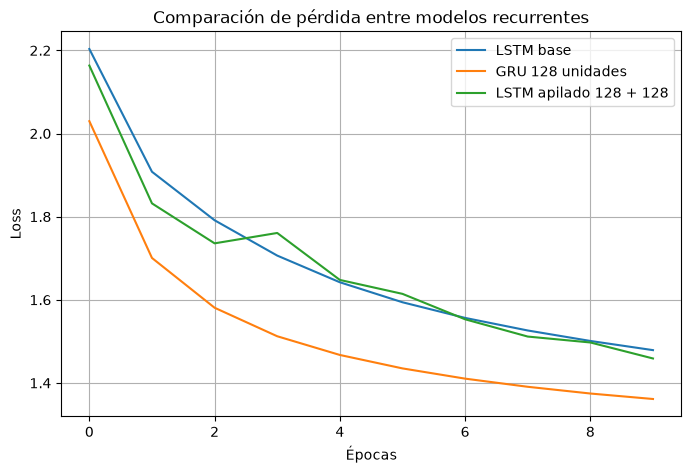

In [ ]:
plt.figure(figsize=(8,5))

for nombre, hist in histories_extra.items():
    plt.plot(hist.history["loss"], label=nombre)

plt.title("Comparación de pérdida entre modelos recurrentes")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

### Análisis de la pérdida entre modelos recurrentes.

En este experimento se compararon tres arquitecturas recurrentes: LSTM base, GRU con 128 unidades y LSTM apilada con dos capas de 128 unidades.

Según la tabla comparativa, el modelo con mejor resultado fue la **GRU de 128 unidades**, obteniendo una pérdida final aproximada de **1.3614**. Luego se ubicó la **LSTM apilada 128 + 128**, con una pérdida cercana a **1.4589**, y finalmente la **LSTM base**, con una pérdida aproximada de **1.4789**.

El gráfico muestra que los tres modelos reducen su pérdida a medida que avanzan las épocas, lo que indica que todas las arquitecturas lograron aprender patrones del texto. Sin embargo, la curva de la GRU se mantiene por debajo de las demás durante todo el entrenamiento, lo que confirma su mejor desempeño en esta prueba.

La LSTM apilada también logra mejorar respecto a la LSTM base, especialmente hacia las últimas épocas. Esto sugiere que agregar una segunda capa recurrente puede aumentar la capacidad del modelo para aprender patrones del corpus. Sin embargo, en este caso no fue suficiente para superar a la GRU.

En conclusión, bajo esta configuración de entrenamiento, la GRU fue la arquitectura recurrente que obtuvo menor pérdida final y, por lo tanto, el mejor resultado cuantitativo dentro de este experimento.

### 4.3.8 Generación de texto con cada modelo.

Además de comparar la pérdida, se genera texto con cada modelo para analizar cualitativamente los resultados.

Se utiliza la misma semilla y temperatura para que la comparación sea más clara.

In [ ]:
seed_text = "en un lugar de la mancha de cuyo nombre"
temperature = 0.5

for nombre, modelo_temp in modelos_extra.items():
    print("\n" + "="*80)
    print(f"Texto generado con modelo: {nombre}")
    print("="*80)

    texto_generado = generate_text(
        seed_text=seed_text,
        model=modelo_temp,
        length=400,
        temperature=temperature
    )

    print(texto_generado)


Texto generado con modelo: LSTM base
en un lugar de la mancha de cuyo nombre la había ser sancho, y si alguna todo lo que ha de profunda de la caballero a sus historias de la compaña.

y no se la para por la caballero, y vuestra malde es los de las señalentes de la cosa y arreción de los las de los que se dicho, en esto, por a la principa de su hija de la compañía su argado y de aquel nocho, con sus palabras, y despenta de la prista que se había mucho de las azcados y las

Texto generado con modelo: GRU 128 unidades
en un lugar de la mancha de cuyo nombre, y del desaficad que estaba estaba en el suelo del parecer la venta, bien por cosa para estaba en la gran tal escudero, que se le debía de allí de un poco de la mancha, y, aunque les vuestra españa a su acudido y de aquellas habían de mis liberas que puedes tenía a don quijote, a lo que está mirar a la cabeza para que es meredía a servir a su señor de lo mesmo caballero
al pensaron la
cabeza, que

Texto generado con modelo: LSTM apil

### 4.3.9 Análisis del experimento con modelos recurrentes.

Este experimento permitió observar cómo influye la arquitectura recurrente en el aprendizaje de un modelo de generación de texto.

La LSTM base fue utilizada como punto de comparación, ya que corresponde a una arquitectura recurrente diseñada para trabajar con secuencias y capturar dependencias temporales.

La GRU se probó como alternativa porque posee una estructura interna más simple que la LSTM. Esto puede hacer que el entrenamiento sea más eficiente, manteniendo la capacidad de aprender relaciones secuenciales dentro del texto.

También se probó una LSTM apilada, que utiliza más de una capa recurrente. Esta variante aumenta la capacidad del modelo, ya que permite aprender representaciones más complejas. Sin embargo, también puede aumentar el costo computacional y requerir más datos o más épocas para aprovechar completamente esa mayor capacidad.

En general, este experimento muestra que cambiar el tipo de red recurrente puede afectar directamente la pérdida del modelo y la calidad del texto generado. Por lo tanto, no solo importa el corpus utilizado, sino también la arquitectura elegida para procesar las secuencias.

---
---

## 4.4 Experimento utilizando embeddings.

En este experimento se reemplaza la representación one-hot encoding por una capa de Embedding.

En el modelo original, cada carácter se representaba mediante one-hot encoding. Esto significa que cada carácter se transformaba en un vector del tamaño total de caracteres únicos, donde solo una posición tenía valor 1 y el resto valor 0.

Aunque one-hot encoding funciona correctamente, puede ser una representación poco eficiente, ya que genera vectores grandes y dispersos. En cambio, una capa `Embedding` aprende una representación densa para cada carácter, usando vectores de menor tamaño.

El objetivo de este experimento es analizar si una representación basada en embeddings permite al modelo aprender patrones del texto de manera más eficiente.

### 4.4.1 Diferencia entre One-Hot Encoding y Embedding.

Con one-hot encoding, cada carácter se representa como un vector largo compuesto principalmente por ceros. Por ejemplo, si existen 80 caracteres únicos, cada carácter se representa con un vector de 80 posiciones.

Con embeddings, cada carácter se representa mediante un vector denso de menor dimensión. Estos vectores no son definidos manualmente, sino que son aprendidos por el modelo durante el entrenamiento.

La ventaja de los embeddings es que reducen el tamaño de la entrada y permiten que el modelo aprenda relaciones internas entre caracteres. Esto puede hacer que el entrenamiento sea más eficiente y que la representación sea más flexible.

### 4.4.2 Creación del dataset para Embedding.

Para usar una capa Embedding, las secuencias de entrada deben estar representadas como índices enteros, no como vectores one-hot.

Por esta razón, cada carácter de la secuencia se convierte a su índice correspondiente usando el diccionario `char_to_indices`.

La variable `X_embed` tendrá forma:

`(número de secuencias, SEQ_LENGTH)`

mientras que `y_embed` contendrá el índice del carácter que el modelo debe predecir.

In [ ]:
def crear_dataset_embedding(text, seq_length, char_to_indices, max_sequences=100000, step=3):
    sequences_embed = []
    next_chars_embed = []

    for i in range(0, len(text) - seq_length, step):
        sequences_embed.append(text[i:i + seq_length])
        next_chars_embed.append(text[i + seq_length])

        if len(sequences_embed) >= max_sequences:
            break

    X_embed = np.zeros((len(sequences_embed), seq_length), dtype=np.int32)
    y_embed = np.zeros((len(sequences_embed),), dtype=np.int32)

    for i, sequence in enumerate(sequences_embed):
        for t, char in enumerate(sequence):
            X_embed[i, t] = char_to_indices[char]

        y_embed[i] = char_to_indices[next_chars_embed[i]]

    return X_embed, y_embed, sequences_embed, next_chars_embed

In [ ]:
## Ahora creamos los datos:
MAX_SEQUENCES_EMBED = 100000
STEP_EMBED = 3

X_embed, y_embed, sequences_embed, next_chars_embed = crear_dataset_embedding(
    text=text,
    seq_length=SEQ_LENGTH,
    char_to_indices=char_to_indices,
    max_sequences=MAX_SEQUENCES_EMBED,
    step=STEP_EMBED
)

print("Shape de X_embed:", X_embed.shape)
print("Shape de y_embed:", y_embed.shape)
print("Ejemplo X_embed:", X_embed[0])
print("Ejemplo y_embed:", y_embed[0])

Shape de X_embed: (100000, 30)
Shape de y_embed: (100000,)
Ejemplo X_embed: [24 22 36 54 40 41 32 35  1 36 38 30 33 26 38 35  9  1 37 41 26  1 40 38
 22 40 22  1 25 26]
Ejemplo y_embed: 1


### 4.4.3 Crear modelo con Embedding + LSTM.

El modelo con Embedding utiliza una capa inicial `Embedding`, encargada de transformar cada índice de carácter en un vector denso.

En este caso, se mantiene una arquitectura recurrente con LSTM para que la comparación con el modelo base sea más justa. La principal diferencia está en la representación de entrada.

La salida sigue siendo una capa `Dense` con activación `softmax`, ya que el modelo debe predecir cuál será el siguiente carácter dentro del conjunto de caracteres posibles.

In [ ]:
from tensorflow.keras.layers import Embedding

def crear_modelo_embedding(seq_length, num_chars, embedding_dim=32):
    model_embed = Sequential()

    model_embed.add(Embedding(
        input_dim=num_chars,
        output_dim=embedding_dim,
        input_length=seq_length
    ))

    model_embed.add(LSTM(128))

    model_embed.add(Dense(num_chars, activation="softmax"))

    model_embed.compile(
        loss="sparse_categorical_crossentropy",
        optimizer="adam"
    )

    return model_embed

In [ ]:
## Creación del modelo:
EMBEDDING_DIM = 32

modelo_embedding = crear_modelo_embedding(
    seq_length=SEQ_LENGTH,
    num_chars=NUM_CHARS,
    embedding_dim=EMBEDDING_DIM
)

modelo_embedding.summary()

c:\Users\Ignacia\Desktop\Don_Quijote\venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### 4.4.4 Entrenamiento del modelo con Embedding.

El modelo se entrena utilizando las secuencias representadas como índices enteros.

A diferencia del modelo con one-hot encoding, aquí la entrada no tiene tres dimensiones con vectores dispersos. En cambio, la capa Embedding aprende internamente una representación densa para cada carácter.

Se utiliza `sparse_categorical_crossentropy` porque las etiquetas `y_embed` están representadas como índices enteros.

In [ ]:
EPOCHS_EMBED = 10
BATCH_SIZE_EMBED = 128

history_embedding = modelo_embedding.fit(
    X_embed,
    y_embed,
    batch_size=BATCH_SIZE_EMBED,
    epochs=EPOCHS_EMBED,
    verbose=1
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 28ms/step - loss: 2.4759
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - loss: 2.1470
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - loss: 2.0308
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - loss: 1.9527
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step - loss: 1.8931
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - loss: 1.8458
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - loss: 1.8045
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - loss: 1.7687
Epoch 9/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - loss: 1.7356
Epoch 10/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - loss: 1.7072


### 4.4.5 Gráfico de pérdida del modelo con Embedding.

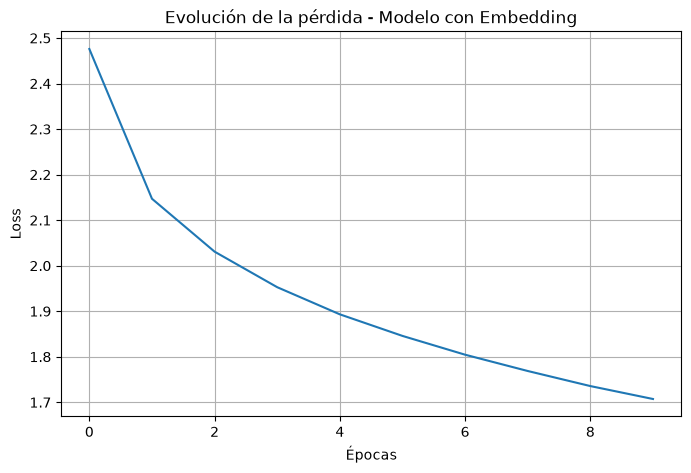

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history_embedding.history["loss"])
plt.title("Evolución de la pérdida - Modelo con Embedding")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

### Análisis de pérdida del modelo con Embedding.

Se observa que la pérdida disminuye progresivamente a medida que avanzas las épocas, comenzando aproximadamente en 2.47 y finalizando cerca de 1.70. Esto indica que el modelo logró aprender patrones del texto y mejorar su capacidad para predecir el siguiente carácter.

La caída más pronunciada ocurre durante las primeras épocas, lo que sugiere que el modelo aprende rápidamente patrones básicos, como combinaciones frecuentes de letras, espacios y estructuras simples del lenguaje.

### 4.4.6 Generación de texto con el modelo Embedding.

Para generar texto con el modelo basado en Embedding, la secuencia de entrada se transforma en índices enteros.

El modelo predice una distribución de probabilidad sobre los posibles caracteres siguientes, y luego se utiliza la función `sample` para seleccionar el próximo carácter según la temperatura indicada.

In [ ]:
def generate_text_embedding(seed_text, model, length, seq_length, temperature=1.0):
    generated = seed_text.lower()

    if len(generated) < seq_length:
        generated = generated.rjust(seq_length)

    for i in range(length):
        sentence = generated[-seq_length:]

        X_pred = np.zeros((1, seq_length), dtype=np.int32)

        for t, char in enumerate(sentence):
            if char in char_to_indices:
                X_pred[0, t] = char_to_indices[char]
            else:
                X_pred[0, t] = 0

        preds = model.predict(X_pred, verbose=0)[0]

        next_index = sample(preds, temperature)
        next_char = indices_to_char[next_index]

        generated += next_char

    return generated

### 4.5.7 Generación de texto con distintas temperaturas.

In [ ]:
seed_text = "en un lugar de la mancha de cuyo nombre"

for temp in [0.2, 0.5, 1.0, 1.2]:
    print("\n" + "="*80)
    print(f"Texto generado con Embedding - Temperatura {temp}")
    print("="*80)

    texto_generado = generate_text_embedding(
        seed_text=seed_text,
        model=modelo_embedding,
        length=400,
        seq_length=SEQ_LENGTH,
        temperature=temp
    )

    print(texto_generado)


Texto generado con Embedding - Temperatura 0.2
en un lugar de la mancha de cuyo nombre de la mancho de las caballero de las caballeros de las caballero de la para de las caballero de las pasar de la para estaba de las caballeros de las comos de las caballeros de la mancho de las caballeros de había de las caballeros de las despaltados de las estas de las cual de la para de las cual de la manto a las prosecido de la mancho de la mancho en esta de la mancho de su caballero de la manc

Texto generado con Embedding - Temperatura 0.5
en un lugar de la mancha de cuyo nombre de sus precidieros de las mantrados y esta de la
viendo a la mancho, y aser porque cosa sancho se la algosas de la venta las comiento de las caballeros que no se hacer y muertos de las adente en la al serced de condidas, y amorra, sin de la había a su más que por el seros puestra sus para de la mancuna de las cual sino por quijote, y al desmos has que la estantua camos de leciento, que no había q

Texto generado con Embe

### 4.4.8 Comparación con modelo One-Hot.

In [ ]:
df_comparacion_embedding = pd.DataFrame({
    "Modelo": [
        "LSTM con One-Hot Encoding",
        "LSTM con Embedding"
    ],
    "Representación de entrada": [
        "One-Hot",
        "Embedding"
    ],
    "Loss final": [
        history.history["loss"][-1],
        history_embedding.history["loss"][-1]
    ],
    "SEQ_LENGTH": [
        SEQ_LENGTH,
        SEQ_LENGTH
    ],
    "Épocas": [
        len(history.history["loss"]),
        len(history_embedding.history["loss"])
    ],
    "Batch size": [
        128,
        BATCH_SIZE_EMBED
    ]
})

df_comparacion_embedding

df_comparacion_embedding.style \
    .format({"Loss final": "{:.4f}"}) \
    .hide(axis="index") \
    .set_caption("Comparación entre One-Hot Encoding y Embedding") \
    .highlight_min(subset=["Loss final"], color="#c8e6c9")

Modelo,Representación de entrada,Loss final,SEQ_LENGTH,Épocas,Batch size
LSTM con One-Hot Encoding,One-Hot,1.4789,30,10,128
LSTM con Embedding,Embedding,1.7072,30,10,128


### 4.4.9 Gráfico comparativo.

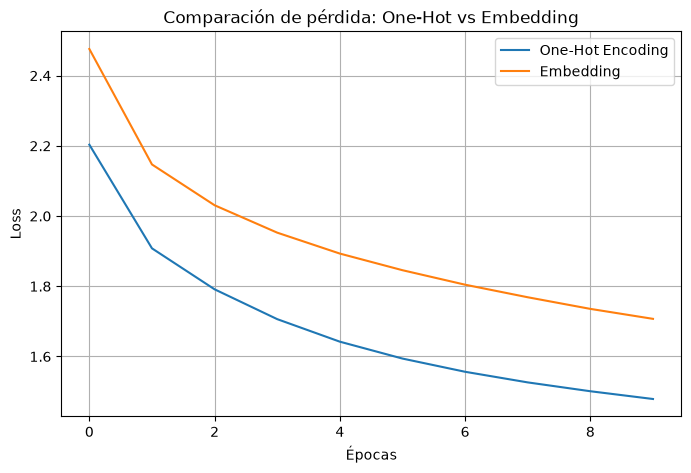

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="One-Hot Encoding")
plt.plot(history_embedding.history["loss"], label="Embedding")

plt.title("Comparación de pérdida: One-Hot vs Embedding")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

### 4.4.10 Análisis del experimento.

En esta comparación se evaluó el rendimiento de dos formas de representar los caracteres: One-Hot Encoding y Embedding.

Según la tabla comparativa, el modelo con One-Hot Encoding obtuvo una pérdida final aproximada de 1.4789, mientras que el modelo con Embedding obtuvo una pérdida final cercana a 1.7072. Por lo tanto, bajo esta configuración, el modelo con One-Hot Encoding obtuvo un mejor desempeño cuantitativo.

El gráfico confirma este comportamiento, ya que la curva del modelo One-Hot se mantiene por debajo de la curva del modelo con Embedding durante todo el entrenamiento. Esto significa que, en cada época, el modelo con One-Hot logró una menor pérdida.

Este resultado no significa que Embedding sea una mala técnica. Una posible explicación es que el modelo con Embedding debe aprender dos cosas al mismo tiempo: la representación densa de cada carácter y la predicción del siguiente carácter. En cambio, One-Hot Encoding entrega desde el inicio una representación directa y separada para cada símbolo.

Además, como el vocabulario de caracteres no es demasiado grande, One-Hot Encoding puede funcionar bien en este caso. Los embeddings suelen ser especialmente útiles cuando se trabaja con vocabularios más grandes, como palabras o subpalabras.

En conclusión, para este experimento, One-Hot Encoding obtuvo mejores resultados que Embedding. Sin embargo, el modelo con Embedding también logró aprender, ya que su pérdida disminuyó de forma continua durante el entrenamiento.


---
---

## 4.5 Modelo secuencia a secuencia.

En los modelos anteriores se trabajó con un enfoque secuencia a carácter. Esto significa que el modelo recibía una secuencia de caracteres y debía predecir únicamente el carácter siguiente.

En este experimento se prueba un enfoque secuencia a secuencia. En este caso, el modelo recibe una secuencia de caracteres y aprende a predecir una secuencia completa desplazada una posición hacia adelante.

Este enfoque permite que el modelo aprenda una predicción en cada instante de la secuencia, no solo al final. Por esta razón, la capa recurrente debe devolver una salida por cada paso temporal, utilizando `return_sequences=True`.

El objetivo de este experimento es analizar si un modelo secuencia a secuencia logra aprender mejor los patrones del texto y generar resultados similares o superiores al enfoque secuencia a carácter.

### 4.5.1 Creación del dataset secuencia a secuencia.

Para construir el dataset secuencia a secuencia, cada entrada contiene una secuencia de caracteres y la salida corresponde a la misma secuencia desplazada un carácter hacia adelante.

Por ejemplo, si la entrada es:

`en un lugar de la mancha`

la salida esperada será:

`n un lugar de la mancha ...`

De esta forma, el modelo aprende a predecir el siguiente carácter en cada posición de la secuencia.

Se utiliza `SEQ_LENGTH = 30` para mantener la comparación con los modelos anteriores. Además, se limita la cantidad de secuencias para evitar un consumo excesivo de memoria.

In [ ]:
SEQ_LENGTH_S2S = 30
MAX_SEQUENCES_S2S = 50000
STEP_S2S = 3

def crear_dataset_seq2seq(text, seq_length, chars, char_to_indices, max_sequences=50000, step=3):
    input_sequences = []
    target_sequences = []

    for i in range(0, len(text) - seq_length - 1, step):
        input_seq = text[i:i + seq_length]
        target_seq = text[i + 1:i + seq_length + 1]

        input_sequences.append(input_seq)
        target_sequences.append(target_seq)

        if len(input_sequences) >= max_sequences:
            break

    num_sequences = len(input_sequences)
    num_chars = len(chars)

    X_s2s = np.zeros((num_sequences, seq_length, num_chars), dtype=np.bool_)
    y_s2s = np.zeros((num_sequences, seq_length), dtype=np.int32)

    for i, sequence in enumerate(input_sequences):
        for t, char in enumerate(sequence):
            X_s2s[i, t, char_to_indices[char]] = 1

        for t, char in enumerate(target_sequences[i]):
            y_s2s[i, t] = char_to_indices[char]

    return X_s2s, y_s2s, input_sequences, target_sequences

In [ ]:
X_s2s, y_s2s, input_sequences_s2s, target_sequences_s2s = crear_dataset_seq2seq(
    text=text,
    seq_length=SEQ_LENGTH_S2S,
    chars=chars,
    char_to_indices=char_to_indices,
    max_sequences=MAX_SEQUENCES_S2S,
    step=STEP_S2S
)

print("Shape de X_s2s:", X_s2s.shape)
print("Shape de y_s2s:", y_s2s.shape)

print("\nEjemplo entrada:")
print(input_sequences_s2s[0])

print("\nEjemplo salida esperada:")
print(target_sequences_s2s[0])

Shape de X_s2s: (50000, 30, 61)
Shape de y_s2s: (50000, 30)

Ejemplo entrada:
capítulo primero. que trata de

Ejemplo salida esperada:
apítulo primero. que trata de 


### 4.5.2 Definición del modelo secuencia a secuencia.

Para este experimento se utiliza una LSTM con `return_sequences=True`.

Este parámetro es necesario porque el modelo debe entregar una predicción en cada paso temporal de la secuencia. Es decir, no se busca predecir solo un carácter final, sino una secuencia completa de caracteres.

Después de la LSTM se utiliza una capa `Dense` con activación `softmax`. Esta capa se aplica en cada paso temporal para obtener una distribución de probabilidad sobre todos los caracteres posibles.

Se mantiene una LSTM de 128 unidades para comparar este modelo con los experimentos anteriores bajo una capacidad similar.

In [ ]:
def crear_modelo_seq2seq(seq_length, num_chars):
    model_s2s = Sequential()

    model_s2s.add(LSTM(
        128,
        return_sequences=True,
        input_shape=(seq_length, num_chars)
    ))

    model_s2s.add(Dense(num_chars, activation="softmax"))

    model_s2s.compile(
        loss="sparse_categorical_crossentropy",
        optimizer="adam"
    )

    return model_s2s

In [ ]:
modelo_seq2seq = crear_modelo_seq2seq(
    seq_length=SEQ_LENGTH_S2S,
    num_chars=NUM_CHARS
)

modelo_seq2seq.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                  │ (None, 30, 128)        │        97,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 30, 61)         │         7,869 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,149 (410.74 KB)

 Trainable params: 105,149 (410.74 KB)

 Non-trainable params: 0 (0.00 B)

### 4.5.3 Entrenamiento del modelo secuencia a secuencia.

El modelo se entrena durante 10 épocas, manteniendo el batch size en 128 para conservar una comparación similar con los experimentos anteriores.

Se utiliza `sparse_categorical_crossentropy` porque la salida `y_s2s` contiene los índices enteros de los caracteres esperados en cada posición de la secuencia.

A diferencia del modelo secuencia a carácter, este modelo calcula pérdida en cada paso temporal, ya que debe predecir una secuencia completa.

In [ ]:
EPOCHS_S2S = 10
BATCH_SIZE_S2S = 128

history_seq2seq = modelo_seq2seq.fit(
    X_s2s,
    y_s2s,
    batch_size=BATCH_SIZE_S2S,
    epochs=EPOCHS_S2S,
    verbose=1
)

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - loss: 2.7347
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 30ms/step - loss: 2.1753
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - loss: 2.0408
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - loss: 1.9659
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - loss: 1.9126
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - loss: 1.8683
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - loss: 1.8290
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 30ms/step - loss: 1.7919
Epoch 9/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 31ms/step - loss: 1.7585
Epoch 10/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 30ms/step - loss: 1.7263


### 4.5.4 Gráfico de pérdida.

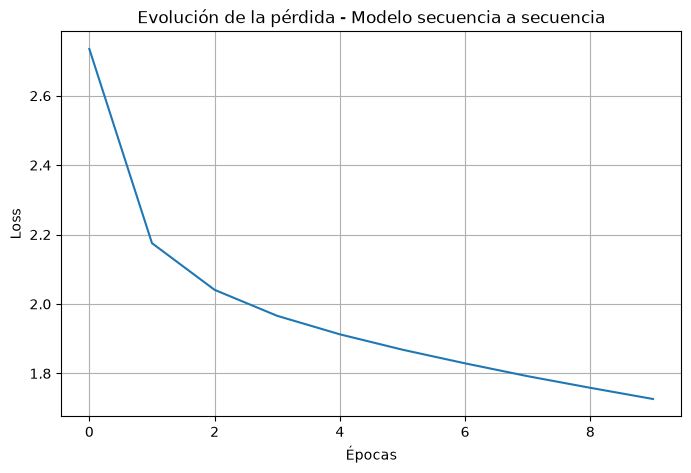

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history_seq2seq.history["loss"])
plt.title("Evolución de la pérdida - Modelo secuencia a secuencia")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

### Análisis de pérdida modelo secuencia a secuencia.

Se observa que la pérdida disminuye progresivamente a medida que avanzan las épocas, comenzando aproximadamente en 2.73 y finalizando cerca de 1.72. Esto indica que el modelo logró aprender patrones del texto y mejorar su capacidad para predecir la secuencia de salida.

La caída más fuerte ocurre durante las primeras épocas, especialmente entre la época 0 y la época 1. Esto sugiere que el modelo aprende rápidamente patrones básicos del texto, como combinaciones frecuentes de caracteres, espacios y estructuras comunes del lenguaje.

En este caso, la tarea es más exigente que en el modelo secuencia a carácter, ya que el modelo no predice solo un carácter final, sino una salida para cada posición de la secuencia. Aun así, la disminución constante de la pérdida muestra que el entrenamiento fue estable y que el modelo sí logró aprender.

### 4.5.5 Generación de texto con modelo secuencia a secuencia.

Aunque el modelo secuencia a secuencia entrega una predicción para cada posición de la entrada, para generar texto se utiliza la predicción del último paso temporal.

Esto permite mantener el proceso autoregresivo: se toma una semilla inicial, se predice el siguiente carácter, se agrega al texto generado y se repite el proceso.

In [ ]:
def generate_text_seq2seq(seed_text, model, length, seq_length, temperature=1.0):
    generated = seed_text.lower()

    if len(generated) < seq_length:
        generated = generated.rjust(seq_length)

    for i in range(length):
        sentence = generated[-seq_length:]

        X_pred = np.zeros((1, seq_length, NUM_CHARS), dtype=np.bool_)

        for t, char in enumerate(sentence):
            if char in char_to_indices:
                X_pred[0, t, char_to_indices[char]] = 1

        preds_seq = model.predict(X_pred, verbose=0)[0]

        # Usamos la predicción del último carácter de la secuencia:
        preds = preds_seq[-1]

        next_index = sample(preds, temperature)
        next_char = indices_to_char[next_index]

        generated += next_char

    return generated

### 4.5.6 Generación de texto con distintas temperaturas.

In [ ]:
seed_text = "en un lugar de la mancha de cuyo nombre"

for temp in [0.2, 0.5, 1.0, 1.2]:
    print("\n" + "="*80)
    print(f"Texto generado con Seq2Seq - Temperatura {temp}")
    print("="*80)

    texto_generado = generate_text_seq2seq(
        seed_text=seed_text,
        model=modelo_seq2seq,
        length=400,
        seq_length=SEQ_LENGTH_S2S,
        temperature=temp
    )

    print(texto_generado)


Texto generado con Seq2Seq - Temperatura 0.2
en un lugar de la mancha de cuyo nombre de la manera a la mana a la caballero y al cual de la venta de la mana de aquello con la mancha, y estaba de la caballero a la mancha, y de la venta a entera de la entantero de la desta de la manera de la caballero de la para de la mana de la mana de la caballero de la arresto de la manera a mancha de la viera de la manera a de aquella de la pasera a la caballeros de la caballero a de de la merce

Texto generado con Seq2Seq - Temperatura 0.5
en un lugar de la mancha de cuyo nombre de aquella así se la argana de muerte de la vuestra de esto que de comado al tantió de aquella otra la mencadado en las armanción que en estar al caballero a sus allos de la mancha, que en el cuerto de la inganto y cuanto a el cual de la caballero, se la vastero de fuero, a lo que al mañora, y así sobre malar a la venta, que él tería la eran miendo desentar en esta en tanado mantado de su trade e

Texto generado con Seq2Seq 

### 4.5.7 Comparación con el modelo secuencia a carácter.

Se compara el modelo secuencia a secuencia con el modelo secuencia a carácter utilizado inicialmente.

Es importante considerar que ambas pérdidas no son completamente equivalentes, ya que el modelo secuencia a carácter predice solo un carácter final, mientras que el modelo secuencia a secuencia predice una salida en cada paso temporal.

Aun así, la comparación permite observar cómo cambia el aprendizaje al modificar la estructura del problema.

In [ ]:
df_comparacion_seq2seq = pd.DataFrame({
    "Modelo": [
        "LSTM secuencia a carácter",
        "LSTM secuencia a secuencia"
    ],
    "Tipo de salida": [
        "Un carácter",
        "Secuencia completa"
    ],
    "Loss final": [
        history.history["loss"][-1],
        history_seq2seq.history["loss"][-1]
    ],
    "SEQ_LENGTH": [
        SEQ_LENGTH,
        SEQ_LENGTH_S2S
    ],
    "Épocas": [
        len(history.history["loss"]),
        len(history_seq2seq.history["loss"])
    ],
    "Batch size": [
        128,
        BATCH_SIZE_S2S
    ]
})

df_comparacion_seq2seq

,Modelo,Tipo de salida,Loss final,SEQ_LENGTH,Épocas,Batch size
0,LSTM secuencia a carácter,Un carácter,1.478926,30,10,128
1,LSTM secuencia a secuencia,Secuencia completa,1.726257,30,10,128


### 4.5.8 Gráfico comparativo.

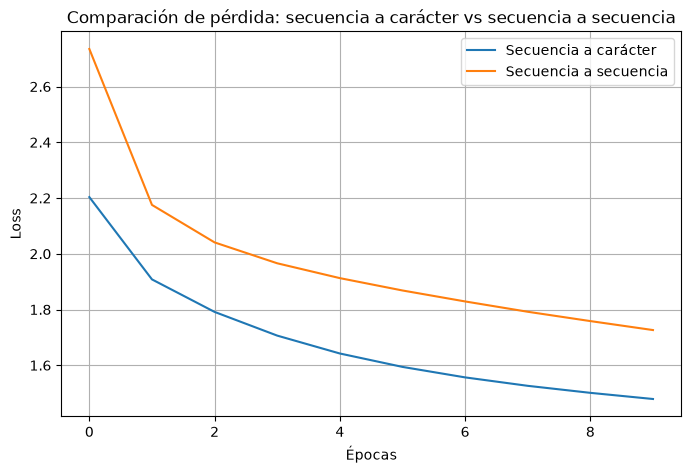

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Secuencia a carácter")
plt.plot(history_seq2seq.history["loss"], label="Secuencia a secuencia")

plt.title("Comparación de pérdida: secuencia a carácter vs secuencia a secuencia")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

### 4.5.9 Análisis del experimento secuencia a secuencia.

En esta comparación se evaluaron dos enfoques de modelado: secuencia a carácter y secuencia a secuencia.

Según la tabla comparativa, el modelo secuencia a carácter obtuvo una pérdida final aproximada de 1.4789, mientras que el modelo secuencia a secuencia obtuvo una pérdida final cercana a 1.7263. Por lo tanto, bajo esta configuración, el modelo secuencia a carácter obtuvo un mejor desempeño cuantitativo.

El gráfico confirma esta diferencia, ya que la curva del modelo secuencia a carácter se mantiene por debajo de la curva del modelo secuencia a secuencia durante todo el entrenamiento.

Esta diferencia es esperable porque ambos modelos resuelven tareas distintas. El modelo secuencia a carácter predice únicamente el siguiente carácter después de una secuencia de entrada. En cambio, el modelo secuencia a secuencia debe predecir una salida para cada posición temporal, lo que aumenta la complejidad del problema.

Para implementar el modelo secuencia a secuencia se utilizó return_sequences=True, permitiendo que la LSTM entregue una salida en cada paso temporal. Esto entrega más señales de aprendizaje, pero también exige que el modelo aprenda una tarea más amplia.

En conclusión, el modelo secuencia a secuencia logró aprender, ya que su pérdida disminuyó de forma constante. Sin embargo, el modelo secuencia a carácter obtuvo mejores resultados en pérdida final para esta configuración de entrenamiento.

---
---

# **Conclusión general.**

En este trabajo se desarrollaron distintos modelos de lenguaje basados en redes recurrentes para generar texto a nivel de caracteres, utilizando principalmente el corpus de *Don Quijote de la Mancha*. El objetivo no fue generar textos literarios completamente coherentes, sino lograr que el modelo aprendiera patrones del texto original y produjera secuencias con palabras reconocibles y estructuras similares al castellano.

Primero se realizó la carga y procesamiento del texto, transformándolo a minúsculas, identificando los caracteres únicos y creando diccionarios para convertir caracteres a índices y viceversa. Luego, se construyeron secuencias de entrada y salidas esperadas, utilizando inicialmente una representación mediante One-Hot Encoding. Esta etapa fue fundamental, ya que permitió transformar el texto en datos numéricos que pudieran ser interpretados por los modelos.

El modelo base utilizado fue una red LSTM secuencia a carácter, donde el modelo recibe una secuencia de caracteres y predice el carácter siguiente. Durante el entrenamiento se observó una disminución progresiva de la pérdida, lo que indica que el modelo fue aprendiendo patrones del texto época a época. Además, al generar texto con distintas temperaturas, se comprobó que valores bajos producen resultados más estables y repetitivos, mientras que valores altos generan mayor variedad, pero también más errores.

Posteriormente se realizaron diversos experimentos opcionales para analizar cómo cambiaba el comportamiento del modelo al modificar distintos elementos. Al probar diferentes valores de `SEQ_LENGTH`, se observó que la cantidad de contexto entregada al modelo influye directamente en el aprendizaje y en el costo computacional. También se compararon distintas arquitecturas recurrentes, donde la GRU obtuvo el mejor resultado en pérdida final bajo la configuración utilizada, superando a la LSTM base y a la LSTM apilada.

Además, se experimentó con una representación mediante Embedding en lugar de One-Hot Encoding. Aunque el modelo con Embedding logró aprender, el modelo con One-Hot Encoding obtuvo una menor pérdida en este caso. Esto demuestra que una técnica más avanzada no siempre entrega mejores resultados automáticamente, ya que su rendimiento depende del tipo de datos, la configuración del modelo y la cantidad de entrenamiento.

También se implementó un modelo secuencia a secuencia, el cual predice una salida para cada posición temporal de la secuencia. Este enfoque resultó más complejo que el modelo secuencia a carácter, ya que debe generar una secuencia completa y no solo un carácter final. Aunque su pérdida fue mayor, el modelo logró aprender, lo que permitió comprender mejor la diferencia entre ambos enfoques.

Finalmente, se realizó un experimento con textos teatrales de Calderón de la Barca. Este corpus presentó un comportamiento diferente al del Quijote, debido a su estructura teatral, presencia de diálogos, versos y cambios de intervención. Aunque la pérdida fue mayor que en el corpus narrativo, el modelo también mostró aprendizaje, evidenciando que el tipo de texto influye directamente en la dificultad del entrenamiento y en el estilo del texto generado.

En conclusión, el trabajo permitió comprender cómo las redes recurrentes pueden utilizarse para generar texto carácter a carácter y cómo distintas decisiones de diseño afectan el resultado final. Aspectos como el largo de secuencia, la arquitectura recurrente, la representación de entrada, el tipo de salida y el corpus utilizado influyen directamente en el aprendizaje del modelo. Si bien los textos generados no alcanzan una coherencia literaria completa, los resultados muestran que los modelos lograron aprender patrones básicos del lenguaje y producir secuencias similares al estilo de los textos trabajados.
